# Continuous HR Comparison (PPG vs rPPG Methods)

This notebook visualize the heart rate (HR) every 10 seconds across a 3-minute signal for:
- Subjects: **s41 to s56**
- Trials: **T1** and **T3**
- Reference signal: **PPG** (`bvp_<subject>_<T>.csv`)
- Estimated signals: **rPPG methods** (`CHROM`, `GREEN`, `LGI`, `OMIT`, `POS`)

Pipeline summary:
1. Load PPG and rPPG signals per subject/trial/method.
2. Align sampling rates (rPPG 35 Hz to 64 Hz).
3. Apply bandpass filtering and normalization.
4. Compute HR in 10-second windows.
5. Plot per-trial HR and error curves for one selected subject.
6. Summarize per-subject metrics and average MAE across subjects by trial-method.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.interpolate import CubicSpline
from scipy.signal import butter, filtfilt, find_peaks

# Scenario configuration
SUBJECTS = [f"s{i}" for i in range(41, 57)]
PLOT_SUBJECT = ["s41", "s42", "s43", "s44", "s45", "s46", "s47", "s48", "s49", "s50", "s51", "s52", "s53", "s54", "s55", "s56"]  # Used only for visualization cells.
TRIALS = ["T1", "T3"]
RPPG_METHODS = ["CHROM", "GREEN", "LGI", "OMIT", "POS"]
DURATION_SEC = 180
WINDOW_SEC = 10
PPG_FS = 64
RPPG_FS = 35
TARGET_FS = 64

In [2]:
def resolve_data_root() -> Path:
    """Find the dataset root folder containing subject directories."""
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd / "dataset_numpy"]
    candidates.extend([parent / "dataset_numpy" for parent in cwd.parents])
    candidates.extend(list(cwd.parents))

    seen = set()
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate in seen:
            continue
        seen.add(candidate)
        if any((candidate / subject).exists() for subject in SUBJECTS):
            return candidate

    raise FileNotFoundError("Could not locate dataset root containing configured subject folders.")


def to_1d_float(signal: np.ndarray) -> np.ndarray:
    arr = np.asarray(signal, dtype=float).squeeze()
    if arr.ndim != 1:
        arr = arr.reshape(-1)
    return arr


def enforce_length(signal: np.ndarray, target_len: int) -> np.ndarray:
    signal = to_1d_float(signal)
    if len(signal) == target_len:
        return signal
    if len(signal) < 2:
        raise ValueError("Signal must contain at least 2 samples.")

    x_old = np.linspace(0.0, 1.0, num=len(signal), endpoint=False)
    x_new = np.linspace(0.0, 1.0, num=target_len, endpoint=False)
    return np.interp(x_new, x_old, signal)


def zscore(signal: np.ndarray) -> np.ndarray:
    signal = to_1d_float(signal)
    std = np.std(signal)
    if std < 1e-8:
        return signal - np.mean(signal)
    return (signal - np.mean(signal)) / std


def bandpass_filter(signal: np.ndarray, fs: int, low_hz: float = 0.7, high_hz: float = 2.5, order: int = 3) -> np.ndarray:
    signal = to_1d_float(signal)
    nyquist = 0.5 * fs
    low = low_hz / nyquist
    high = min(high_hz / nyquist, 0.99)
    b, a = butter(order, [low, high], btype="bandpass")
    return filtfilt(b, a, signal)


def preprocess_ppg(ppg_signal: np.ndarray, fs: int, target_len: int) -> np.ndarray:
    aligned = enforce_length(ppg_signal, target_len)
    filtered = bandpass_filter(aligned, fs)
    return zscore(filtered)


def preprocess_rppg(rppg_signal: np.ndarray, src_fs: int, dst_fs: int, target_len: int) -> np.ndarray:
    rppg_signal = to_1d_float(rppg_signal)
    duration = len(rppg_signal) / float(src_fs)

    t_src = np.linspace(0.0, duration, num=len(rppg_signal), endpoint=False)
    t_dst = np.linspace(0.0, duration, num=int(round(duration * dst_fs)), endpoint=False)

    spline = CubicSpline(t_src, rppg_signal, extrapolate=False)
    upsampled = spline(t_dst)
    if np.isnan(upsampled).any():
        upsampled = np.nan_to_num(upsampled, nan=float(np.nanmean(rppg_signal)))

    aligned = enforce_length(upsampled, target_len)
    filtered = bandpass_filter(aligned, dst_fs)
    return zscore(filtered)


def compute_window_hr(window_signal: np.ndarray, fs: int, base_prominence: float = 0.5) -> float:
    window_signal = to_1d_float(window_signal)
    min_distance = max(1, int(0.35 * fs))

    for prominence in (base_prominence, 0.35, 0.2):
        peaks, _ = find_peaks(window_signal, prominence=prominence, distance=min_distance)
        if len(peaks) < 2:
            continue

        rr_intervals = np.diff(peaks) / float(fs)
        rr_valid = rr_intervals[(rr_intervals >= 0.3) & (rr_intervals <= 2.0)]
        if rr_valid.size == 0:
            continue

        return 60.0 / np.mean(rr_valid)

    return np.nan

In [3]:
data_root = resolve_data_root()

target_len = DURATION_SEC * TARGET_FS
window_size = WINDOW_SEC * TARGET_FS
num_windows = target_len // window_size

all_rows = []
missing_files = []
missing_subjects = []
processed_subjects = set()

for subject in SUBJECTS:
    subject_dir = data_root / subject
    if not subject_dir.exists():
        missing_subjects.append(subject)
        continue

    for trial in TRIALS:
        ppg_path = subject_dir / f"bvp_{subject}_{trial}.csv"
        if not ppg_path.exists():
            missing_files.append(str(ppg_path))
            continue

        ppg_raw = np.loadtxt(ppg_path, delimiter=",")
        ppg_processed = preprocess_ppg(ppg_raw, PPG_FS, target_len)

        ppg_hr_series = []
        for idx in range(num_windows):
            start = idx * window_size
            end = start + window_size
            ppg_window = ppg_processed[start:end]
            ppg_hr_series.append(compute_window_hr(ppg_window, TARGET_FS))

        for method in RPPG_METHODS:
            rppg_path = subject_dir / f"{subject}_{trial}_{method}_rppg.npy"
            if not rppg_path.exists():
                missing_files.append(str(rppg_path))
                continue

            rppg_raw = np.load(rppg_path)
            rppg_processed = preprocess_rppg(rppg_raw, RPPG_FS, TARGET_FS, target_len)

            for idx in range(num_windows):
                start = idx * window_size
                end = start + window_size

                hr_ppg = ppg_hr_series[idx]
                hr_rppg = compute_window_hr(rppg_processed[start:end], TARGET_FS)

                signed_error = hr_rppg - hr_ppg if np.isfinite(hr_ppg) and np.isfinite(hr_rppg) else np.nan
                abs_error = abs(signed_error) if np.isfinite(signed_error) else np.nan

                all_rows.append(
                    {
                        "subject": subject,
                        "trial": trial,
                        "method": method,
                        "time_s": idx * WINDOW_SEC,
                        "hr_ppg_bpm": hr_ppg,
                        "hr_rppg_bpm": hr_rppg,
                        "signed_error_bpm": signed_error,
                        "abs_error_bpm": abs_error,
                    }
                )

            processed_subjects.add(subject)

comparison_df = pd.DataFrame(all_rows)
if comparison_df.empty:
    raise RuntimeError("No comparison rows were created. Check file paths and naming.")

print(f"Data root: {data_root}")
print(f"Rows generated: {len(comparison_df)}")
print(f"Processed subjects: {sorted(processed_subjects)}")
print(f"Trials found: {sorted(comparison_df['trial'].unique().tolist())}")
print(f"Methods found: {sorted(comparison_df['method'].unique().tolist())}")
print(f"Windows per trial-method: {num_windows}")

if missing_subjects:
    print("Missing subject directories:")
    for s in missing_subjects:
        print(f"- {s}")

if missing_files:
    print("Missing files detected:")
    for p in sorted(set(missing_files)):
        print(f"- {p}")

comparison_df.head(12)

Data root: D:\UBFC-Phys\workflow-research\dataset_numpy
Rows generated: 2880
Processed subjects: ['s41', 's42', 's43', 's44', 's45', 's46', 's47', 's48', 's49', 's50', 's51', 's52', 's53', 's54', 's55', 's56']
Trials found: ['T1', 'T3']
Methods found: ['CHROM', 'GREEN', 'LGI', 'OMIT', 'POS']
Windows per trial-method: 18


,subject,trial,method,time_s,hr_ppg_bpm,hr_rppg_bpm,signed_error_bpm,abs_error_bpm
0,s41,T1,CHROM,0,100.065147,100.863039,0.797893,0.797893
1,s41,T1,CHROM,10,102.127660,99.826690,-2.300970,2.300970
2,s41,T1,CHROM,20,96.160267,90.964467,-5.195800,5.195800
3,s41,T1,CHROM,30,99.826690,91.428571,-8.398118,8.398118
4,s41,T1,CHROM,40,92.307692,92.788104,0.480412,0.480412
5,s41,T1,CHROM,50,101.408451,101.052632,-0.355819,0.355819
6,s41,T1,CHROM,60,96.969697,96.806723,-0.162974,0.162974
7,s41,T1,CHROM,70,99.139415,99.256866,0.117451,0.117451
8,s41,T1,CHROM,80,94.426230,95.319149,0.892919,0.892919
9,s41,T1,CHROM,90,105.748709,107.978910,2.230201,2.230201


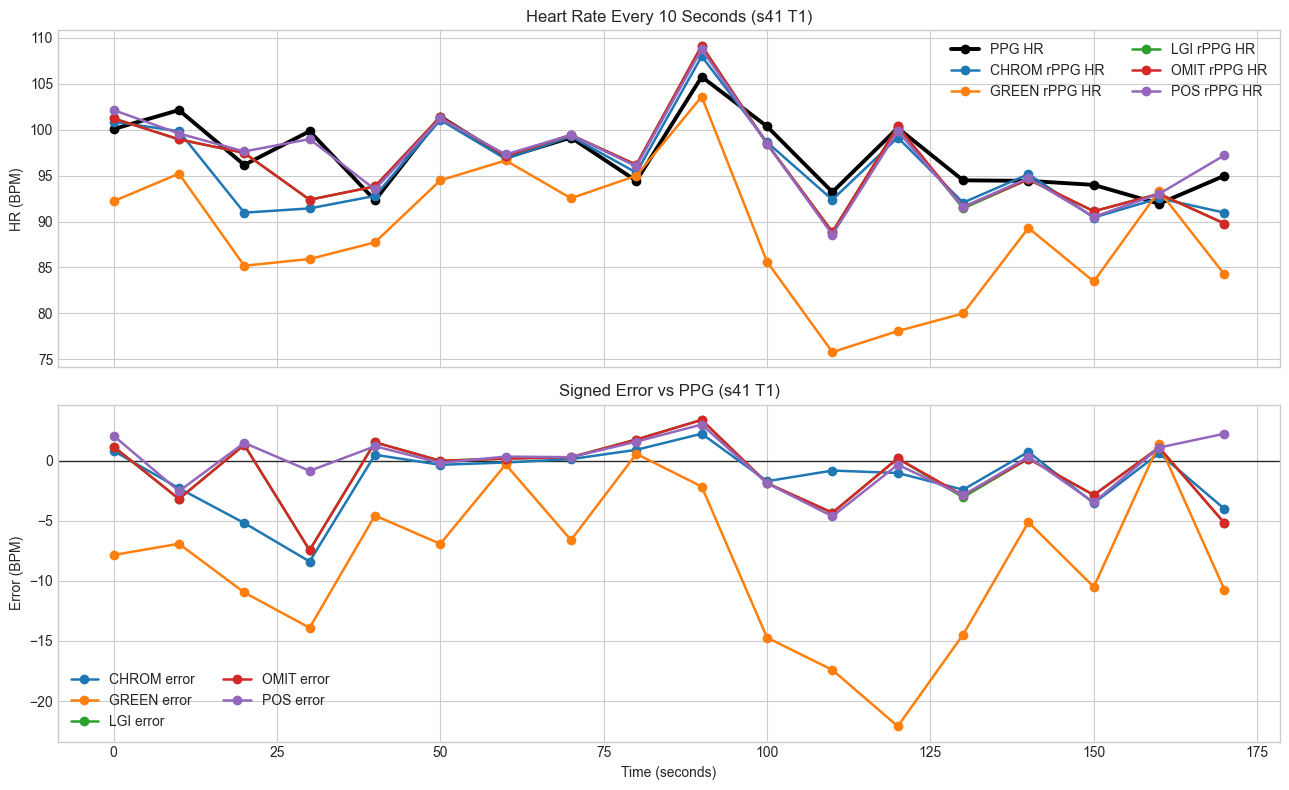

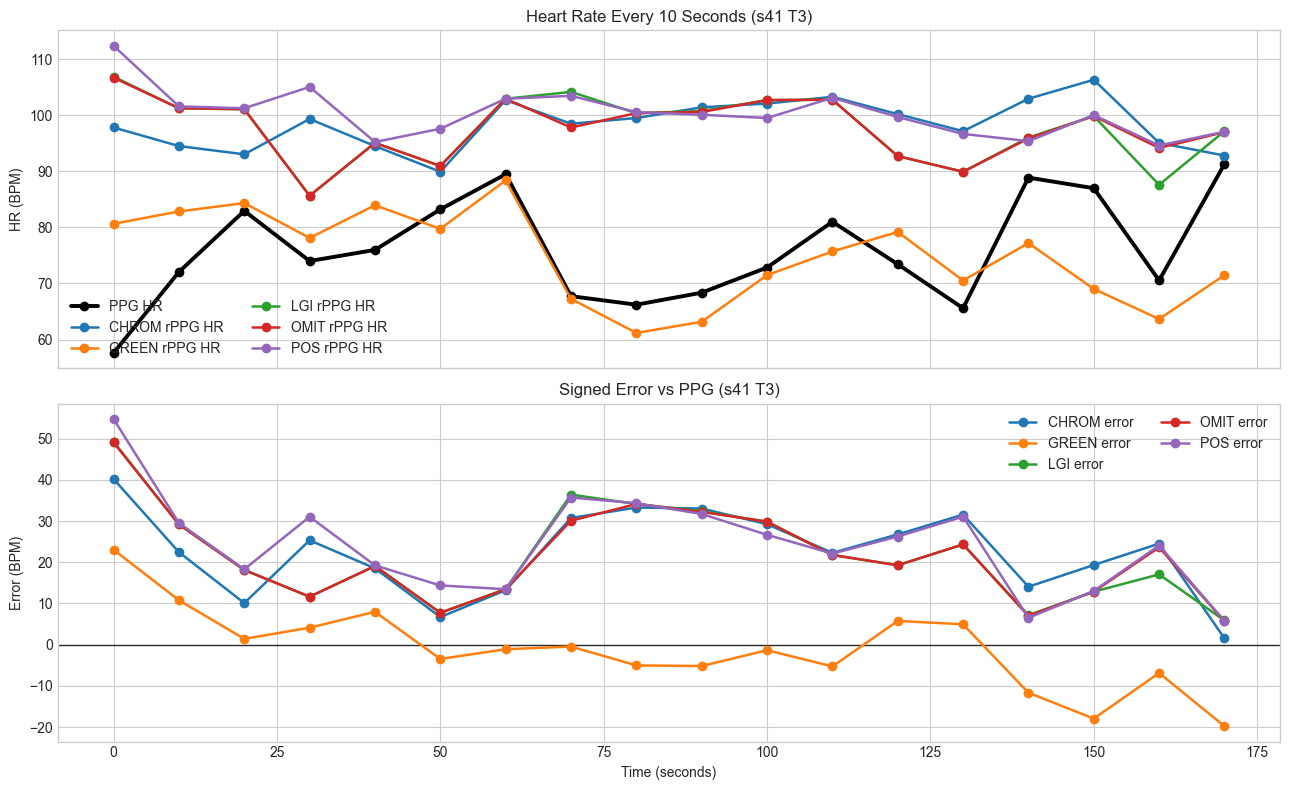

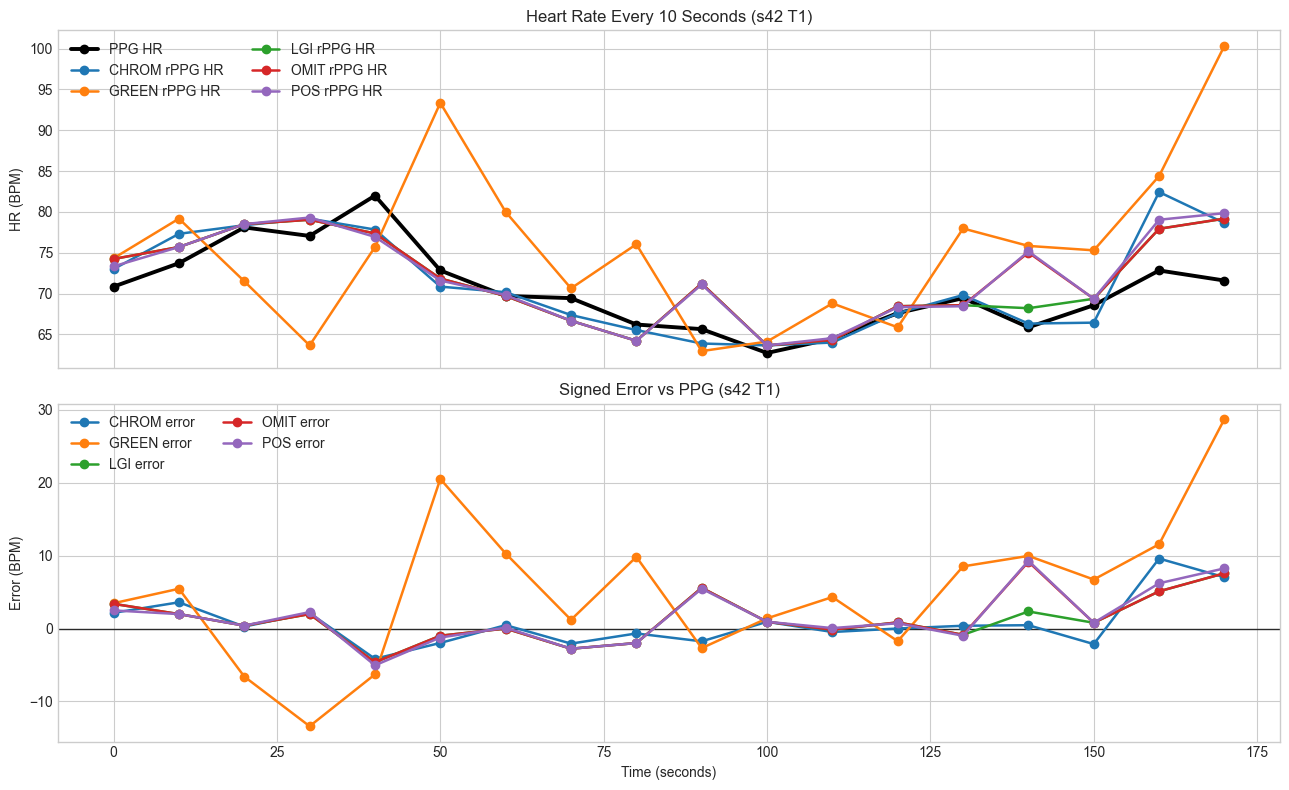

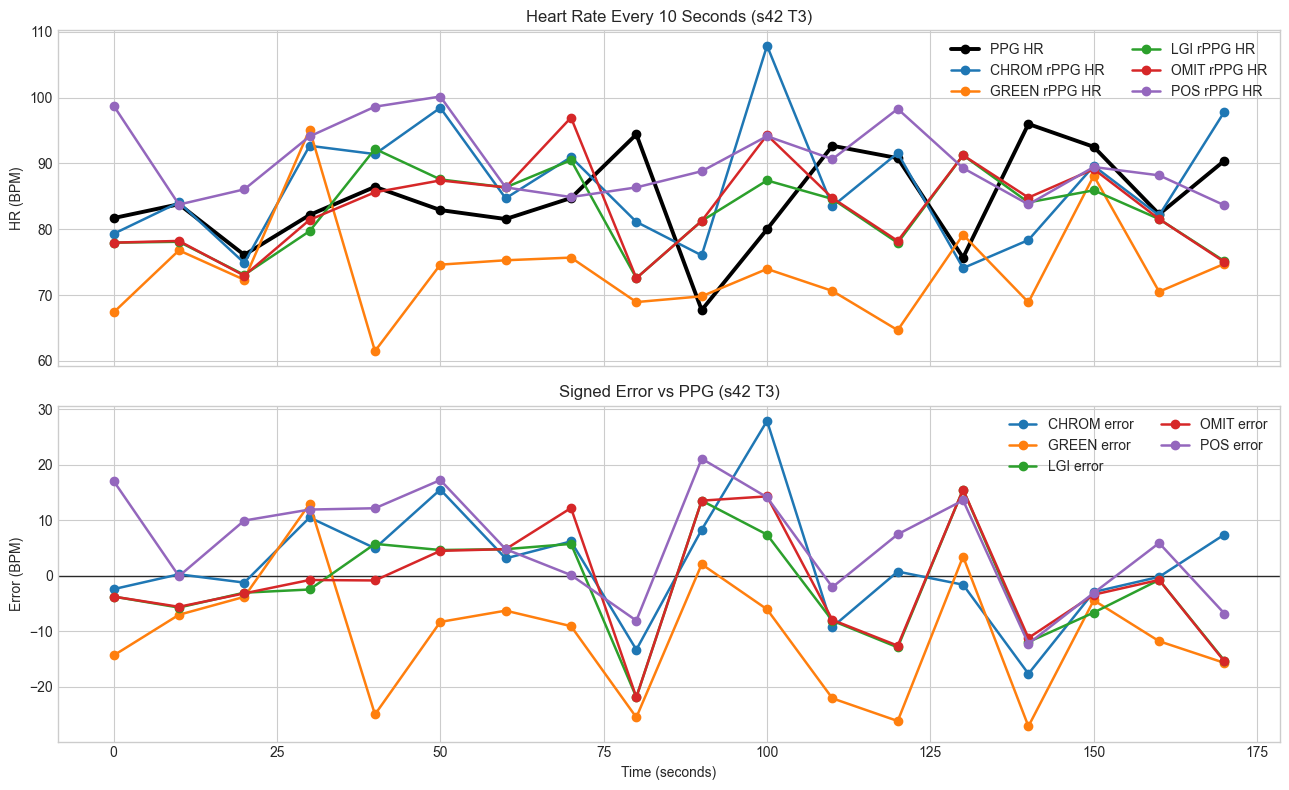

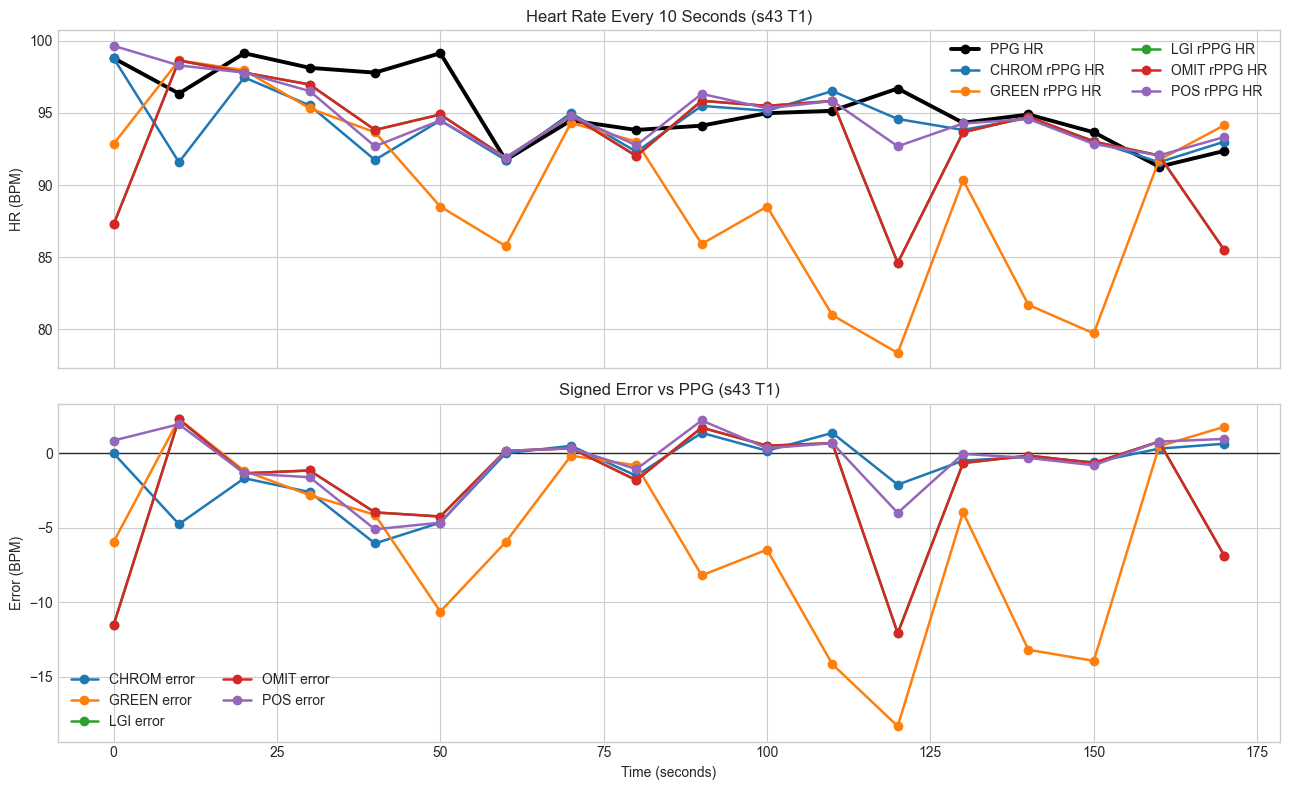

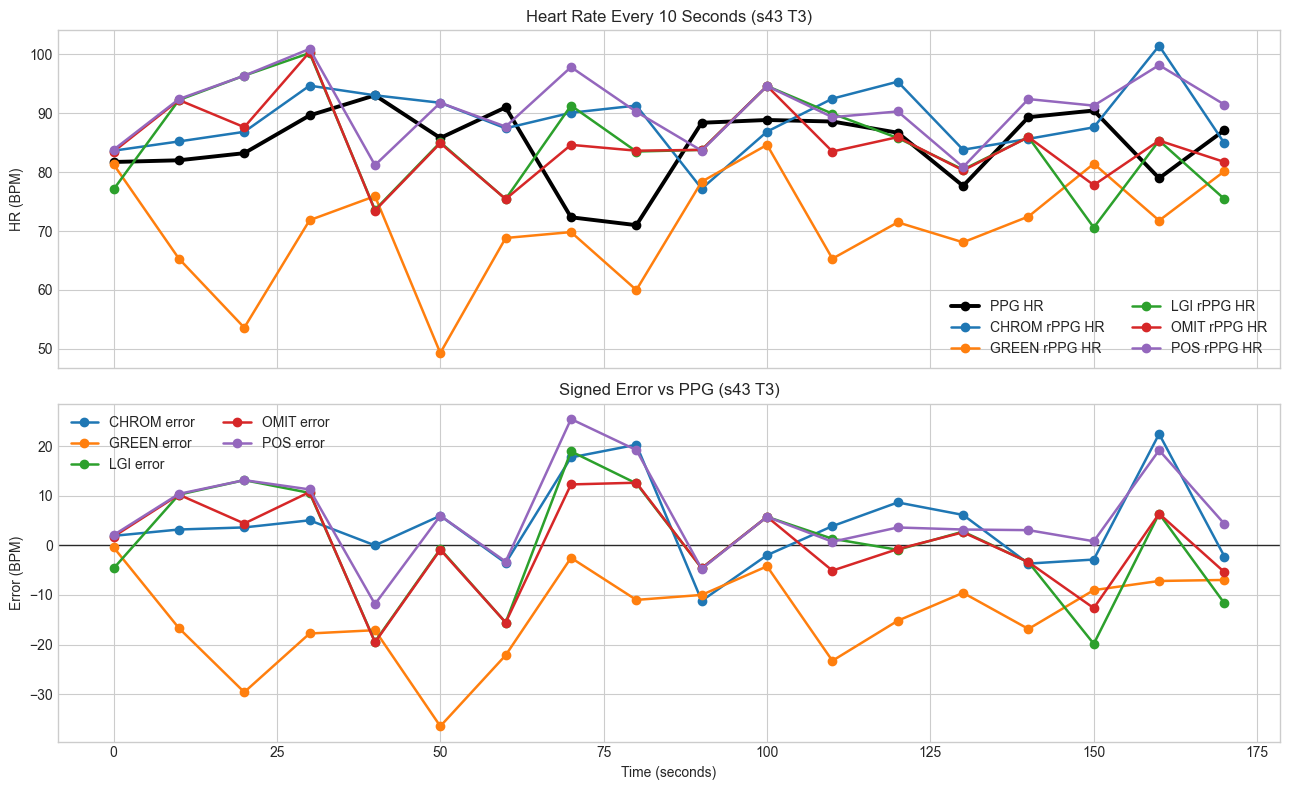

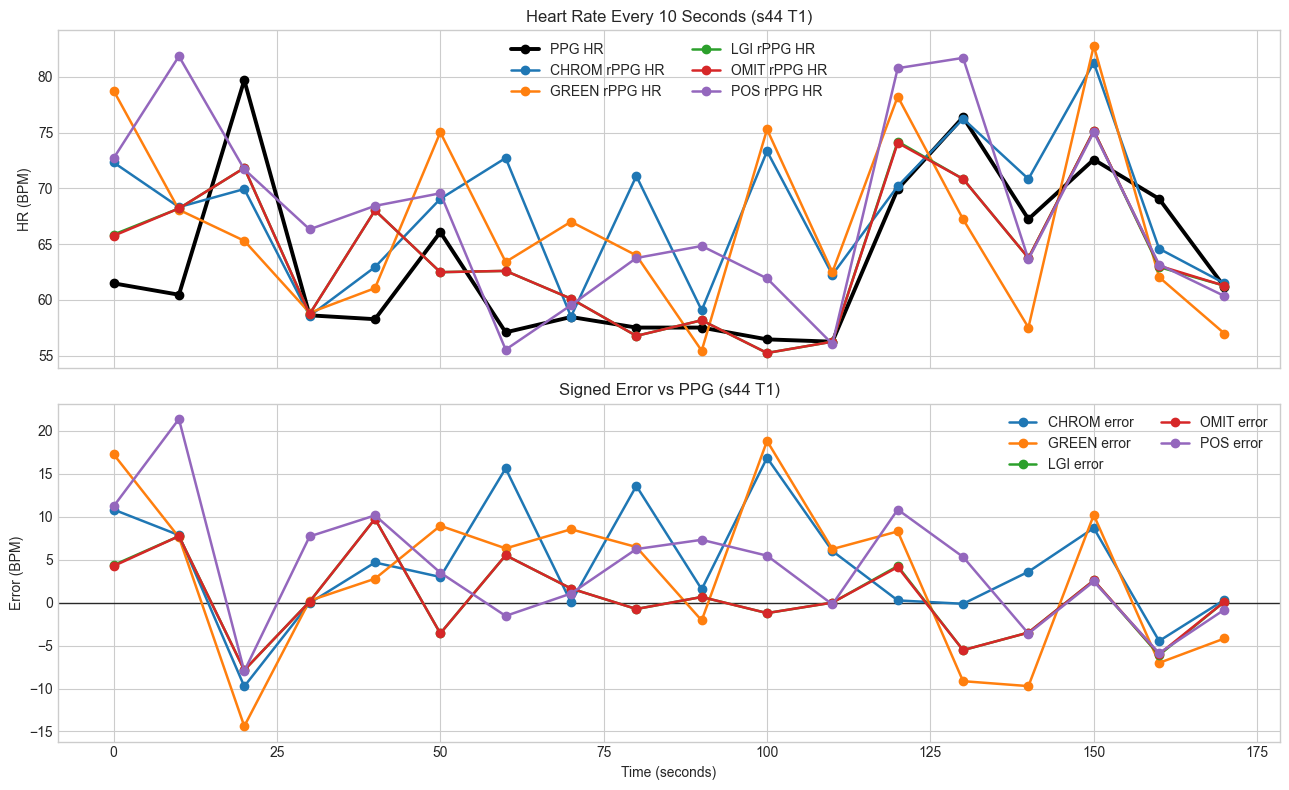

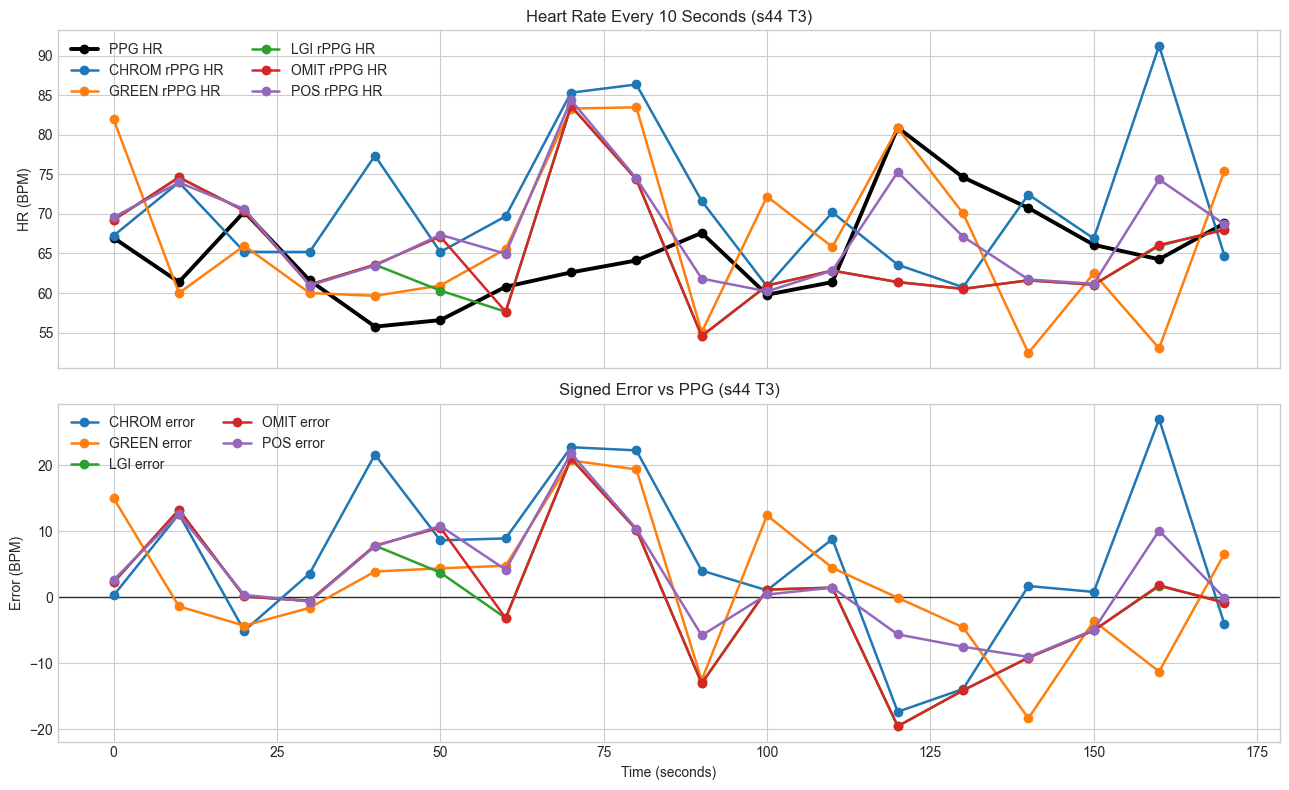

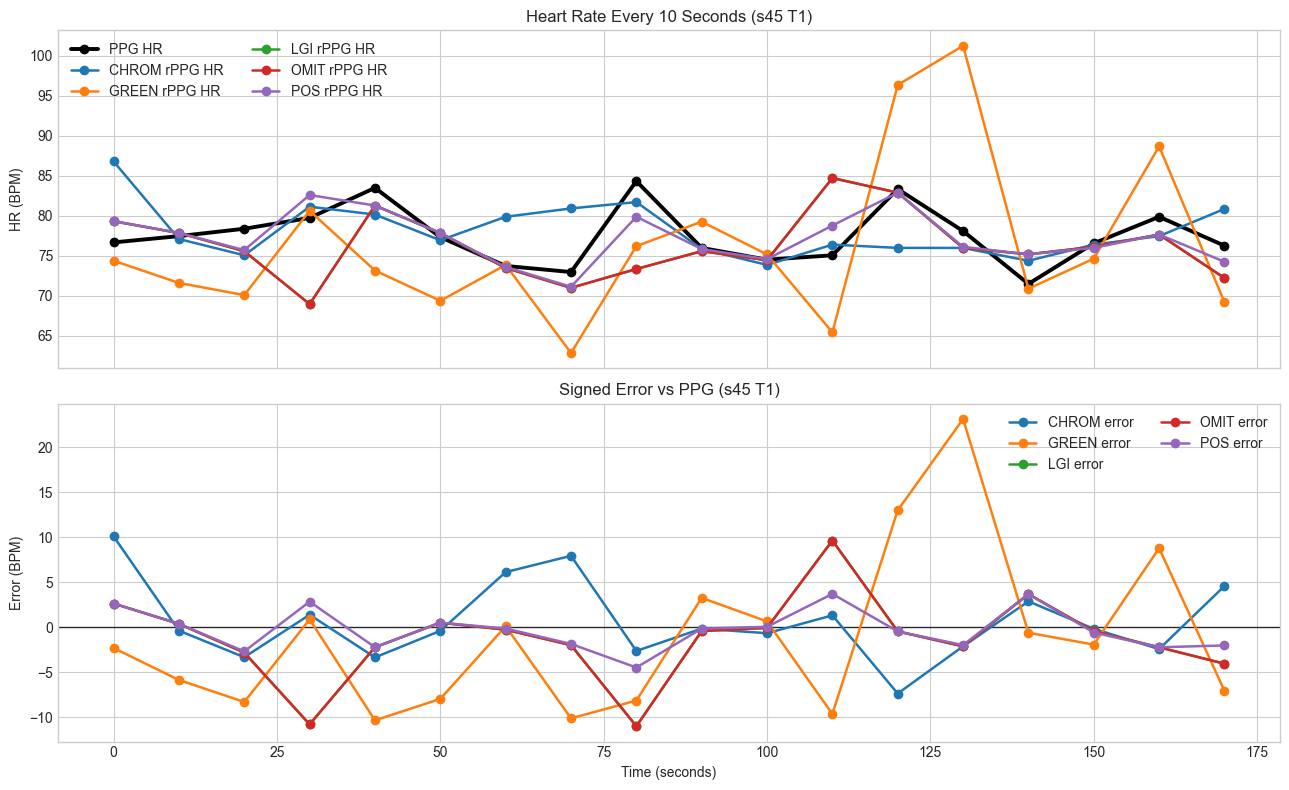

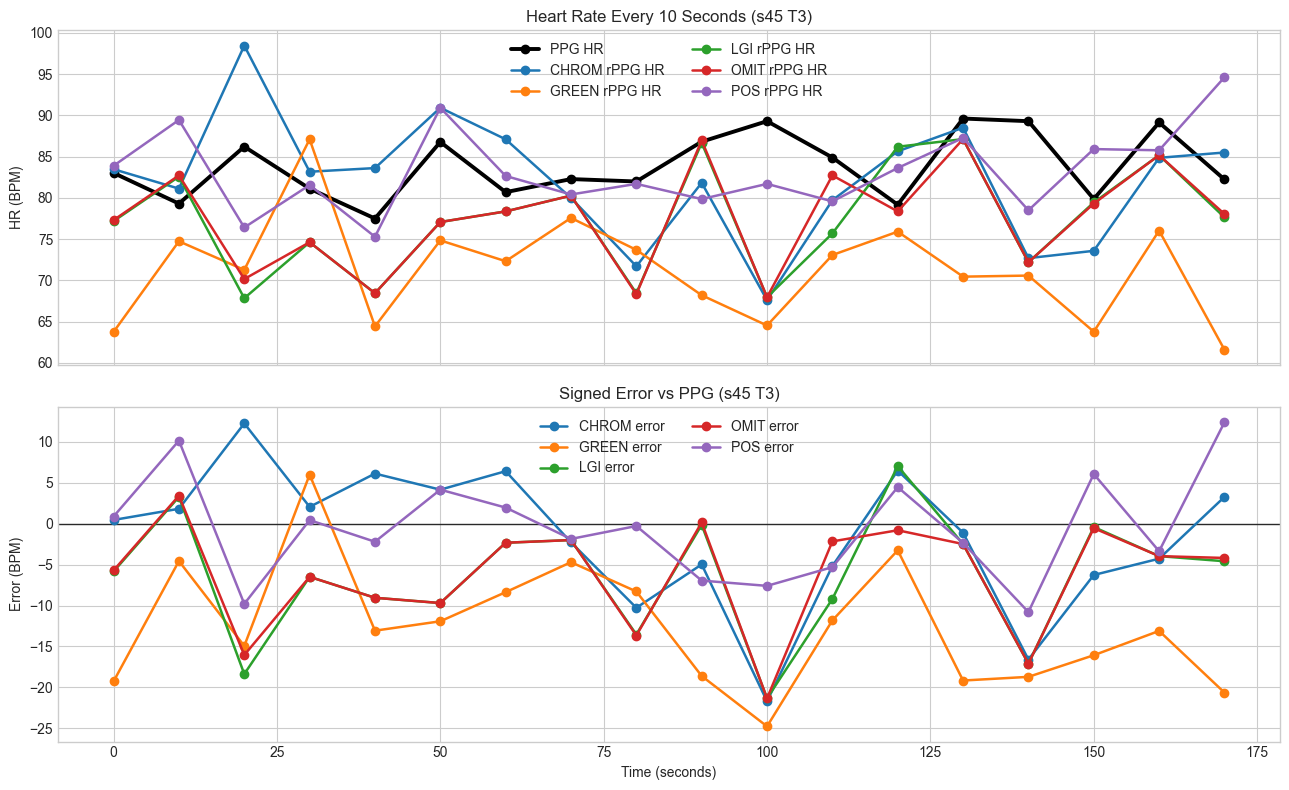

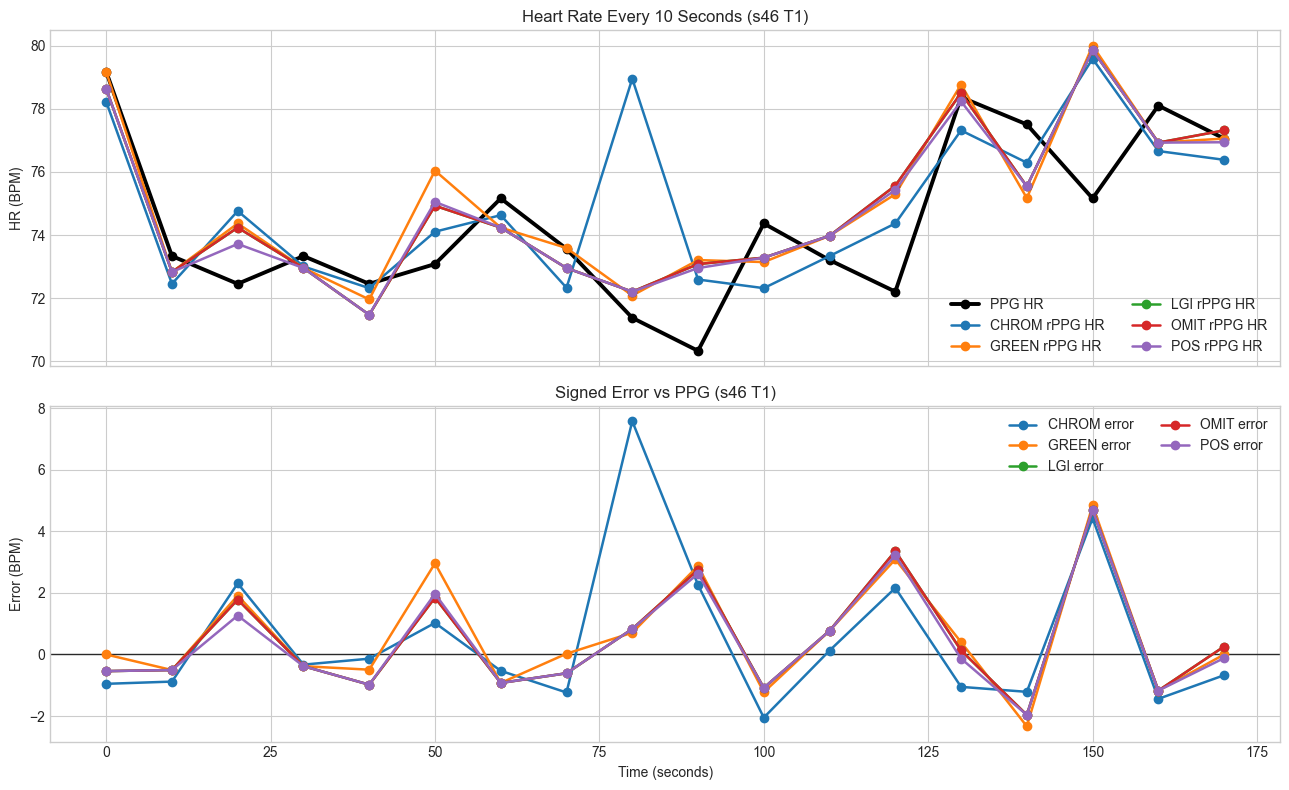

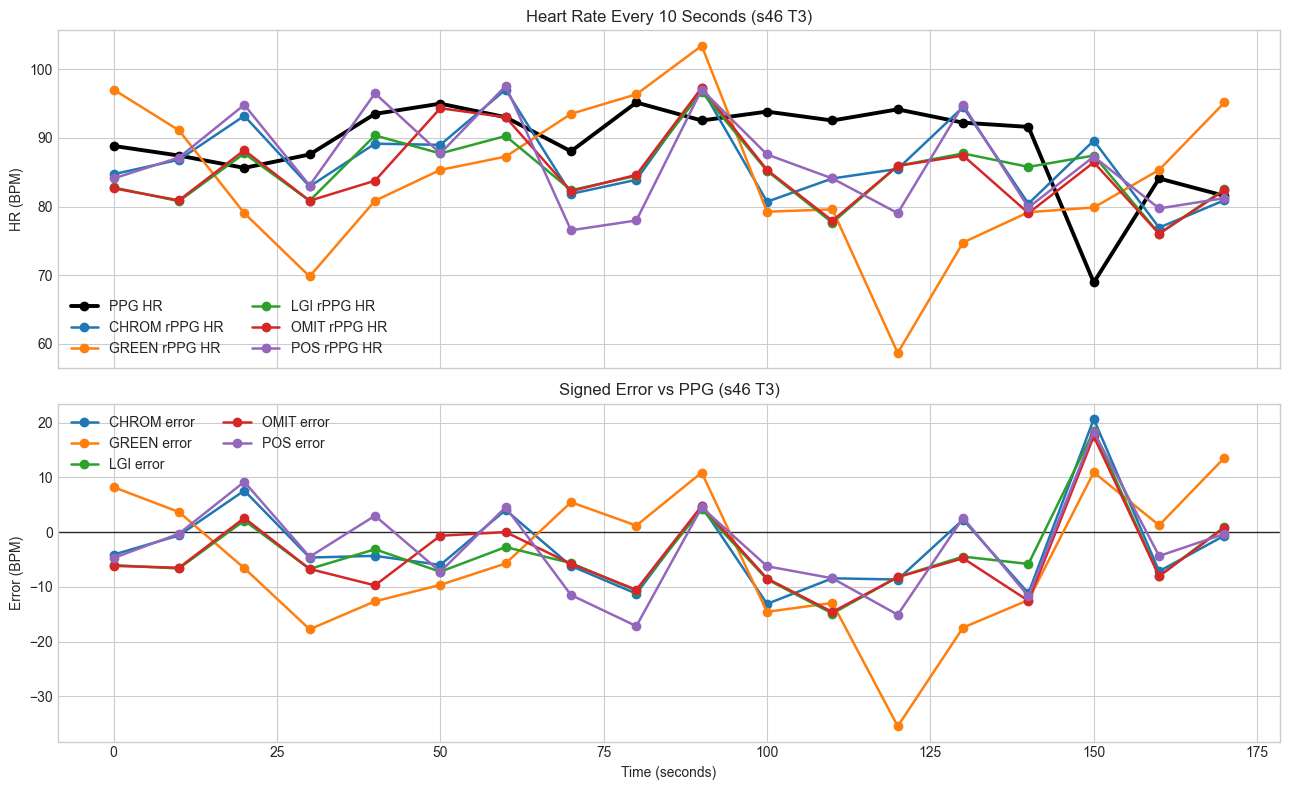

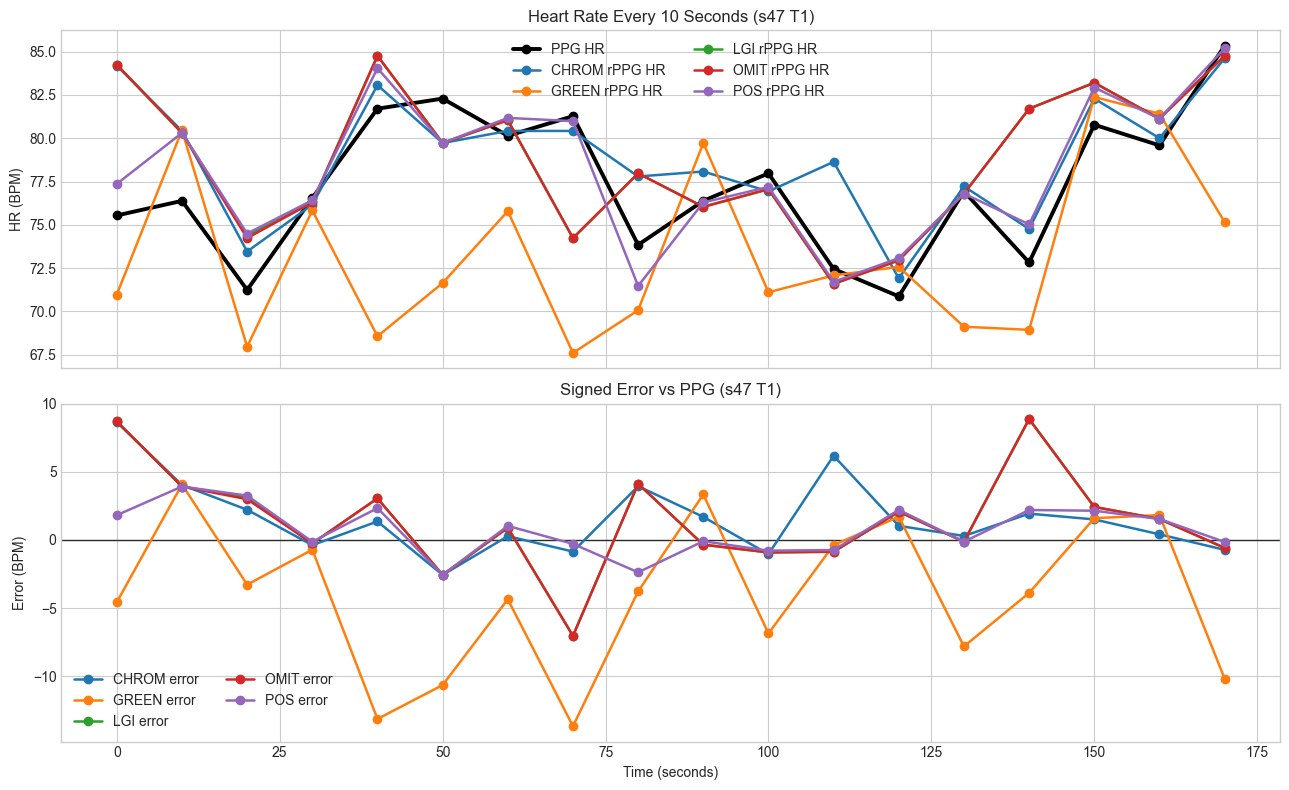

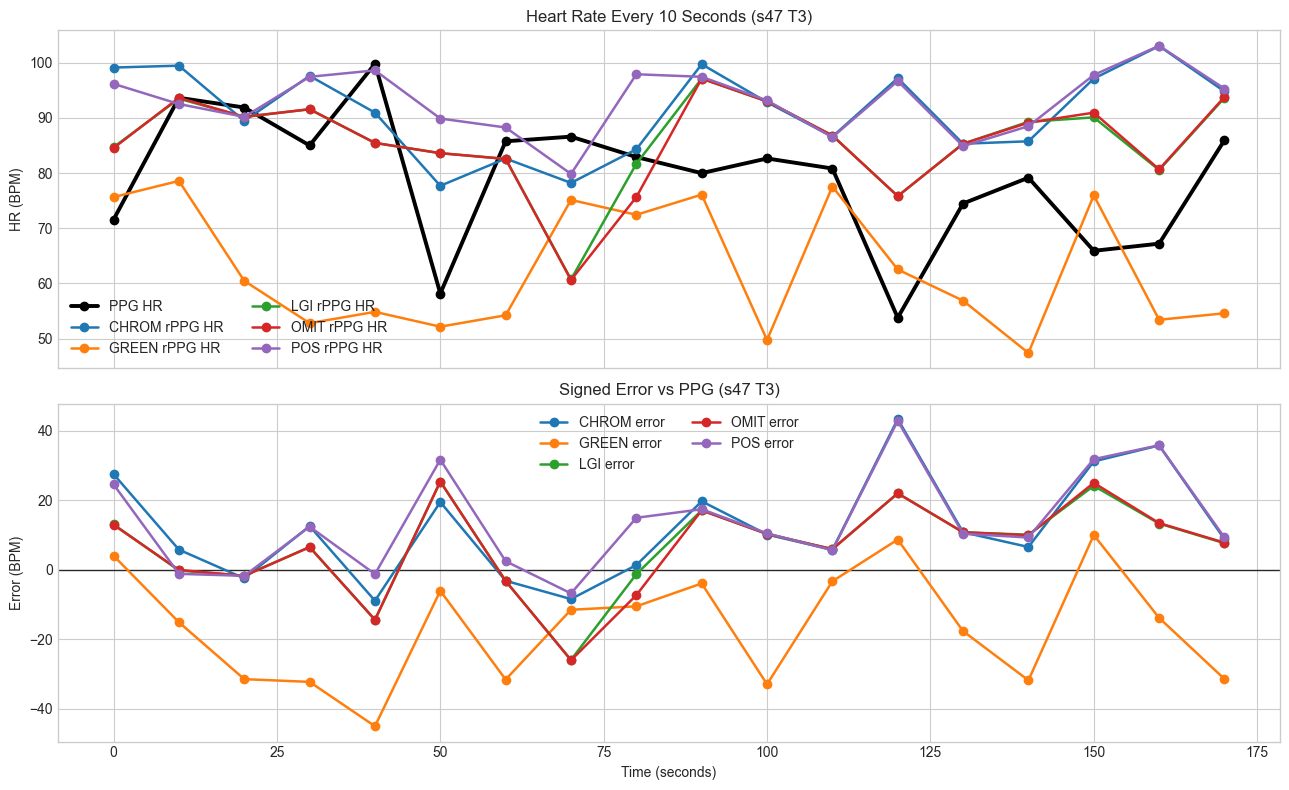

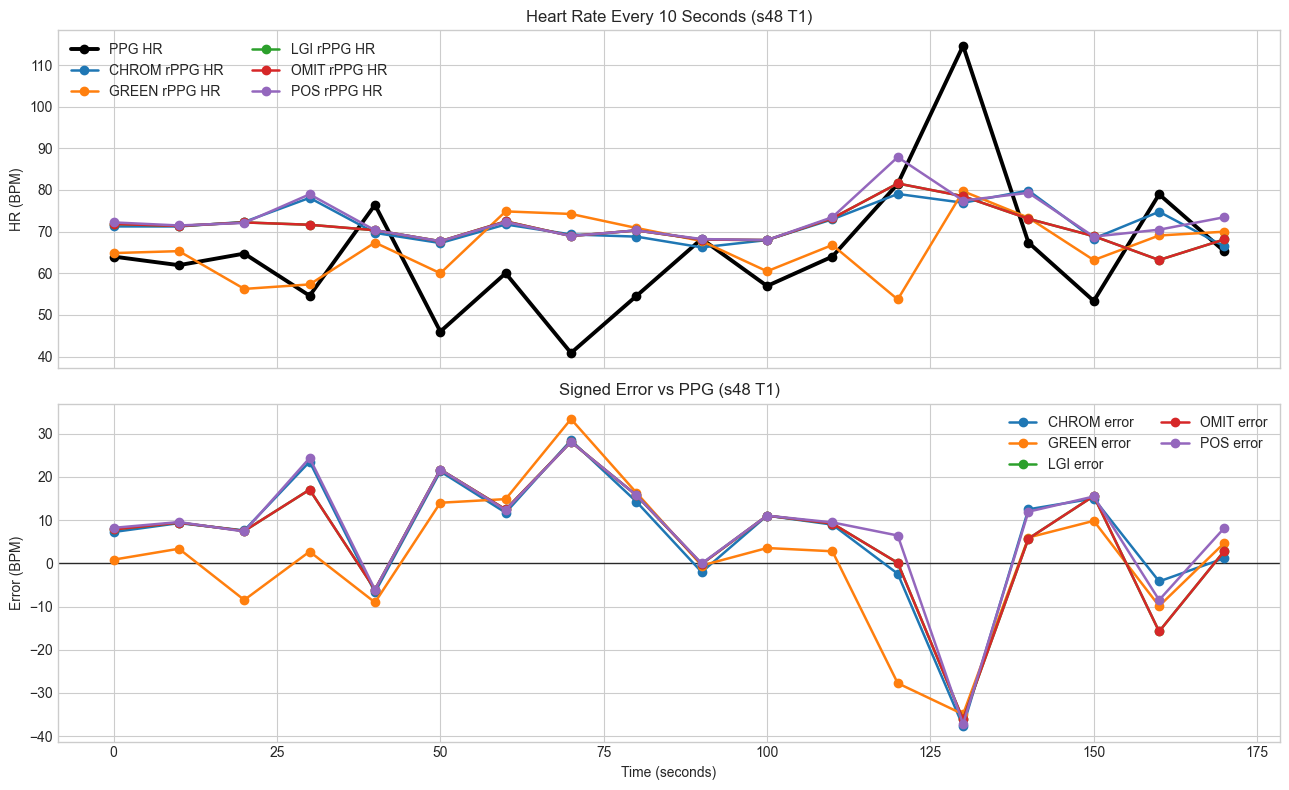

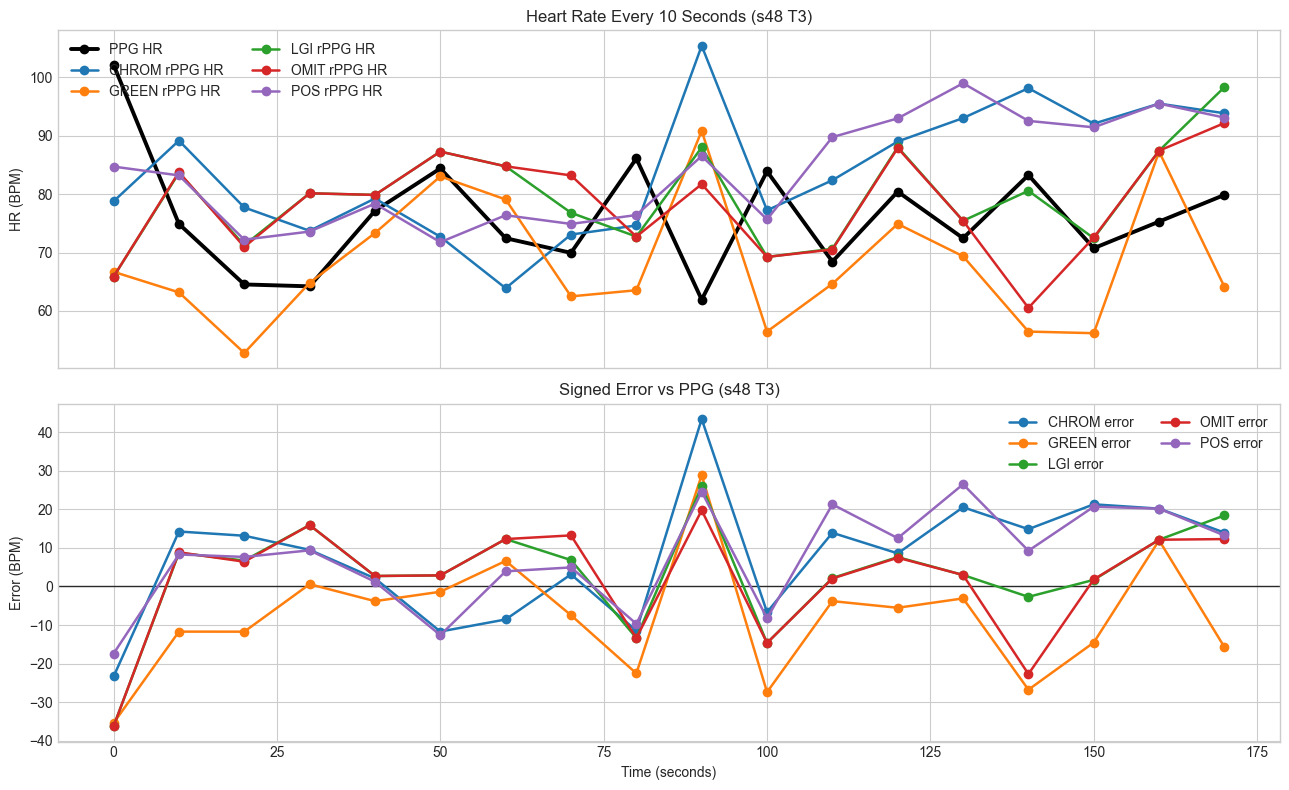

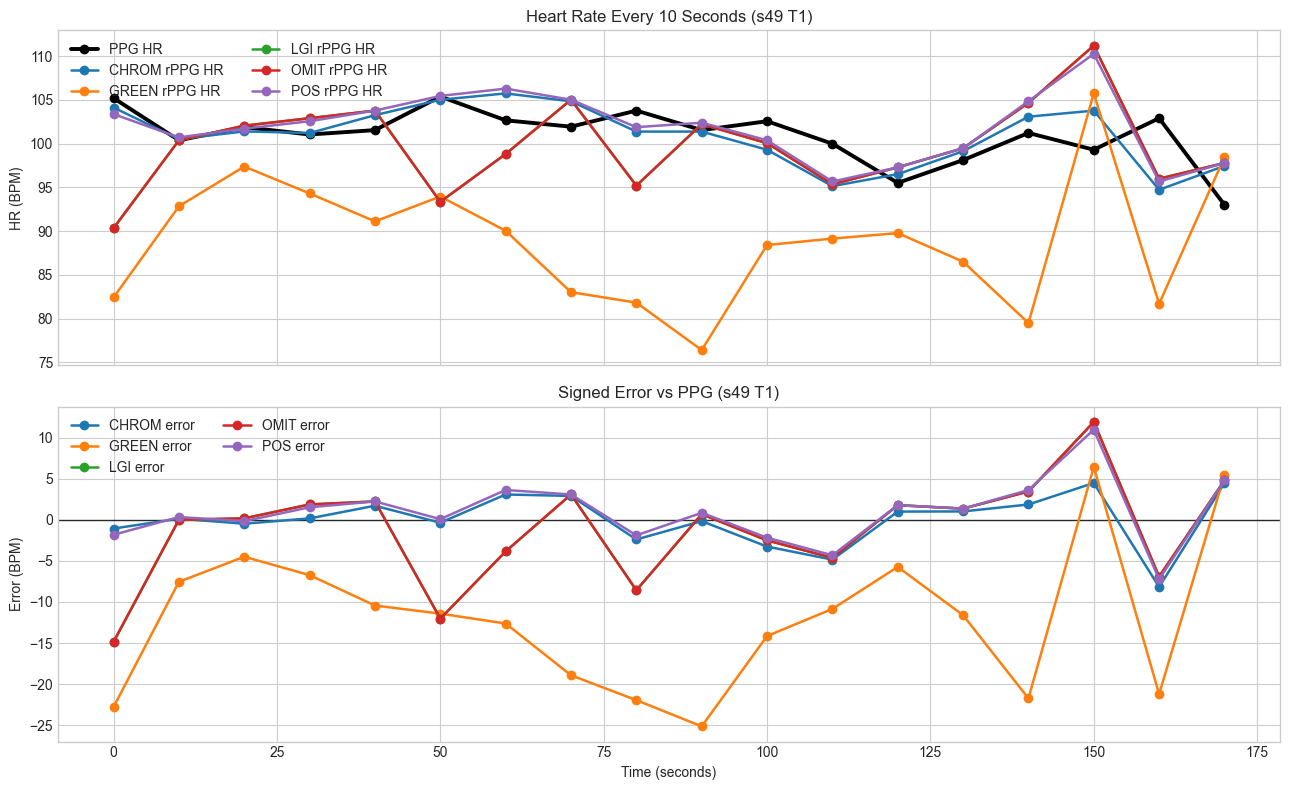

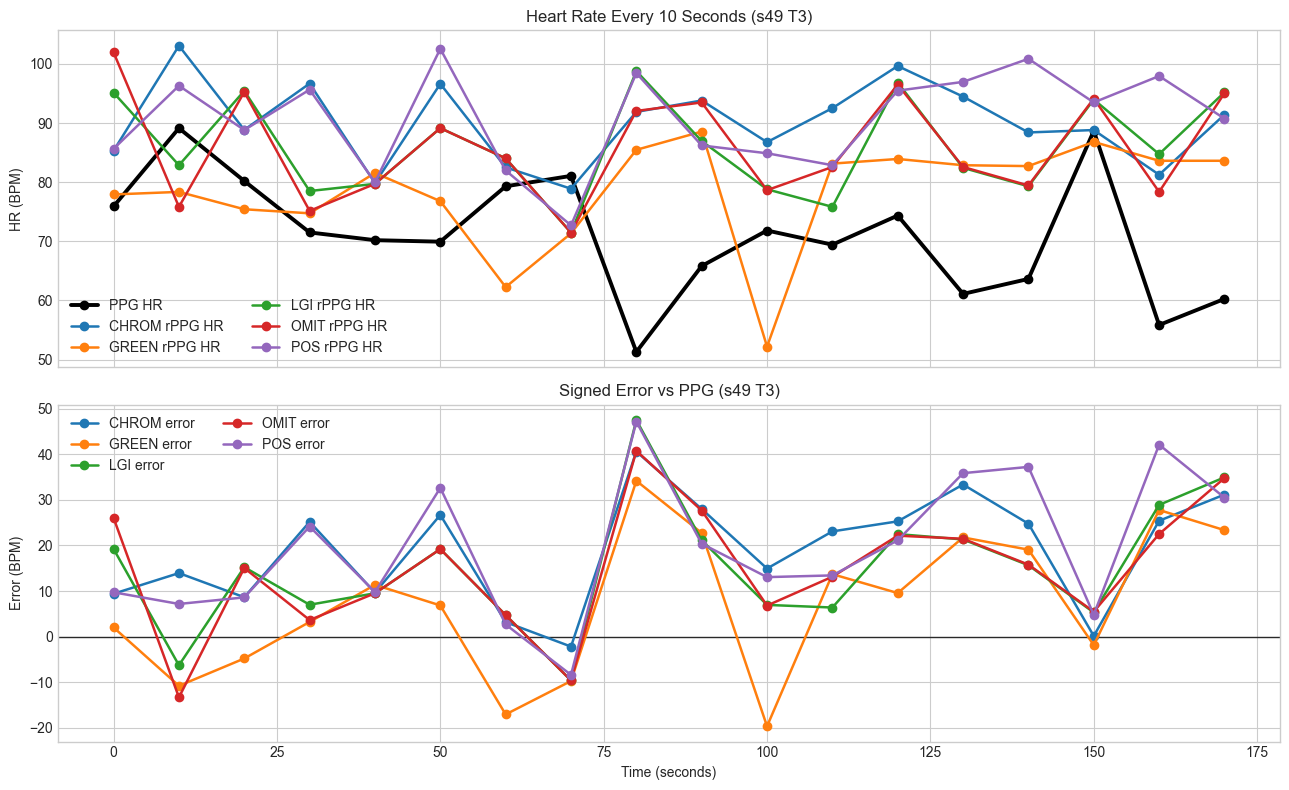

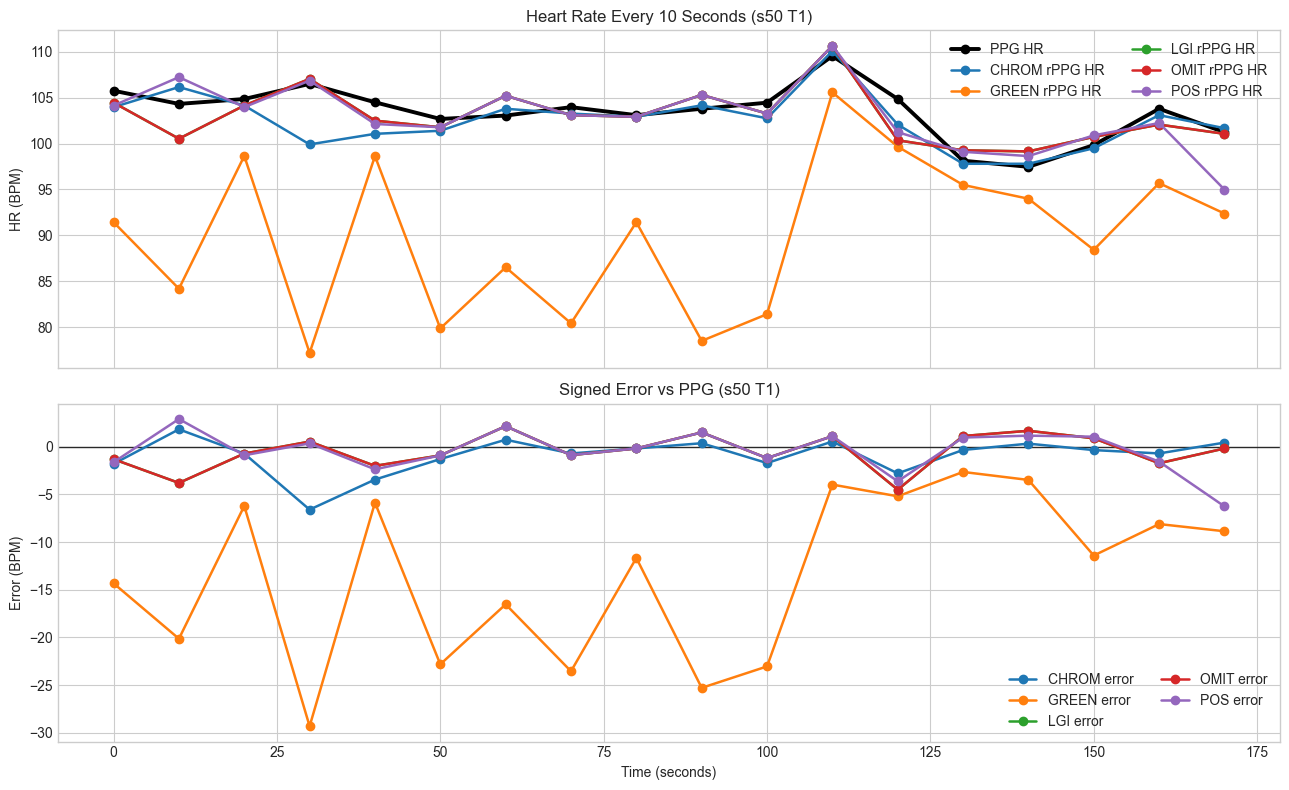

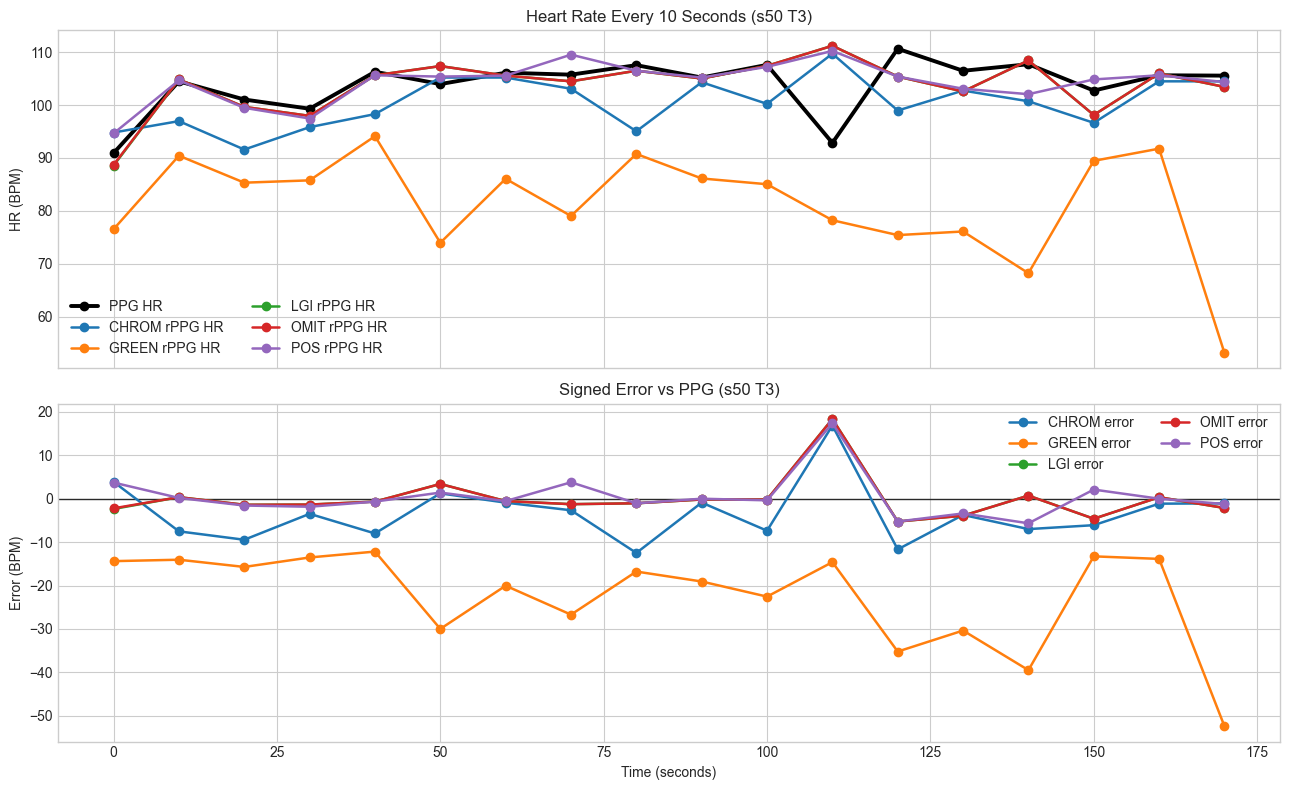

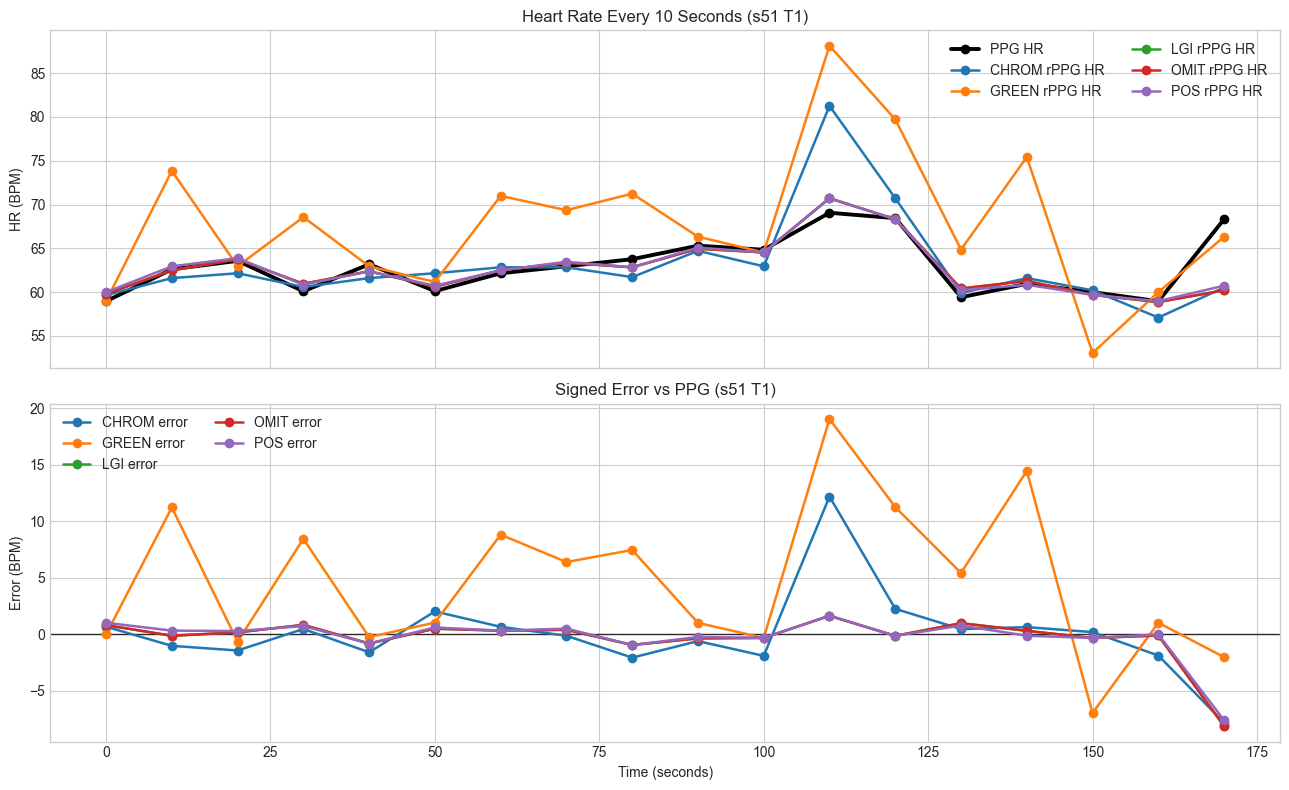

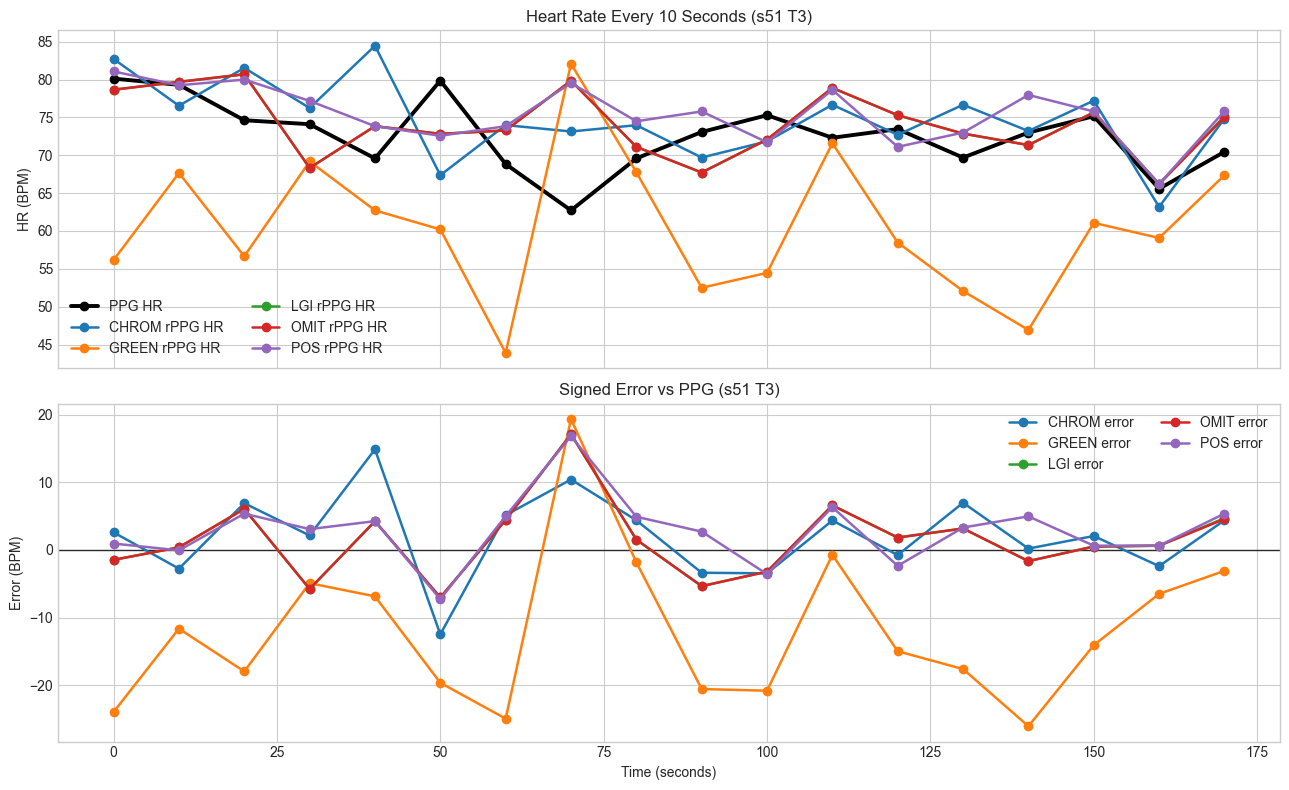

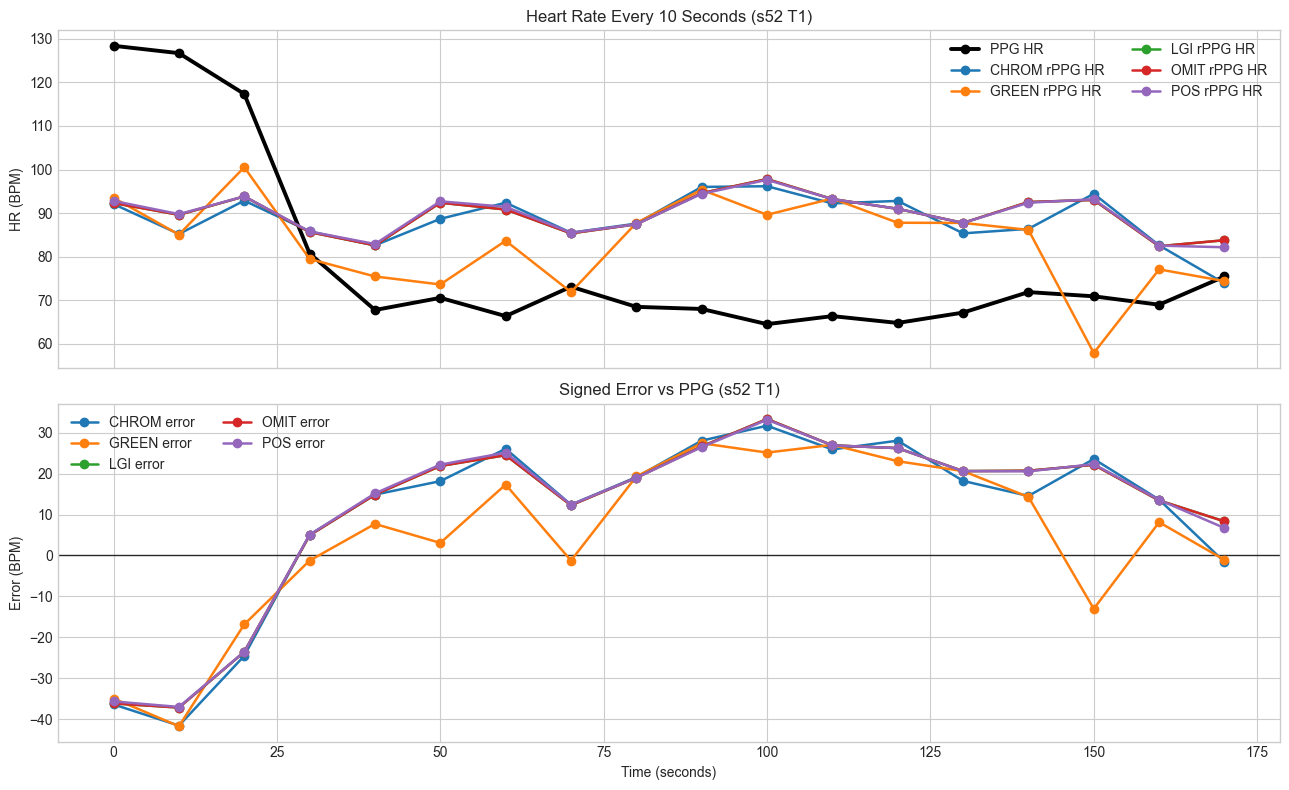

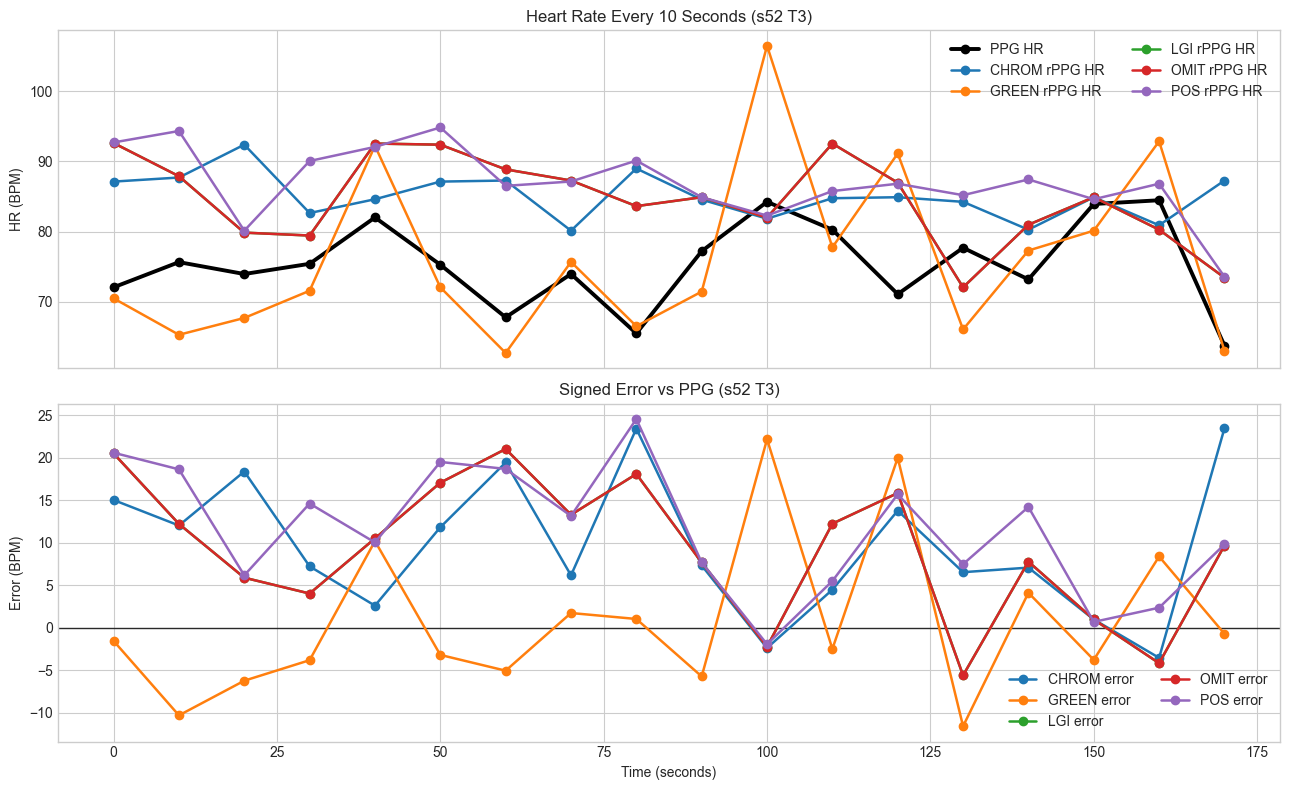

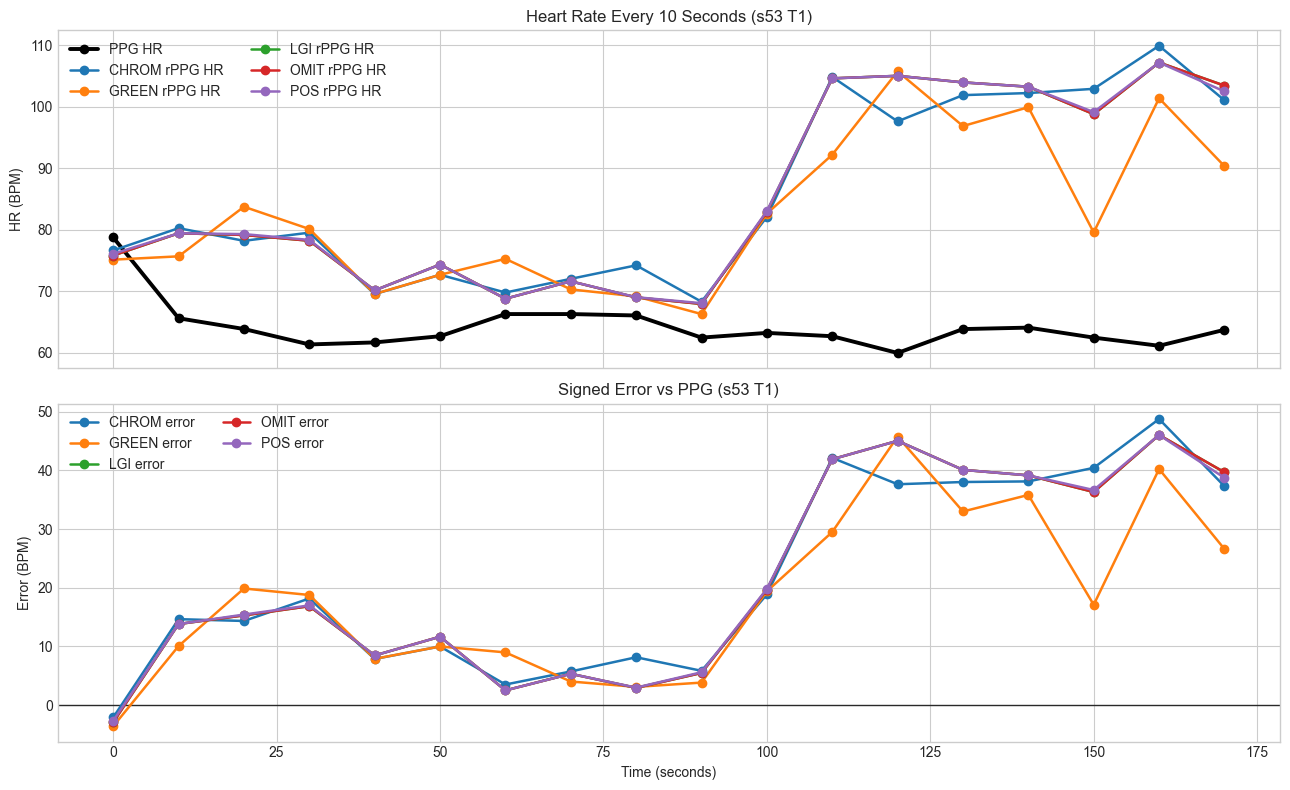

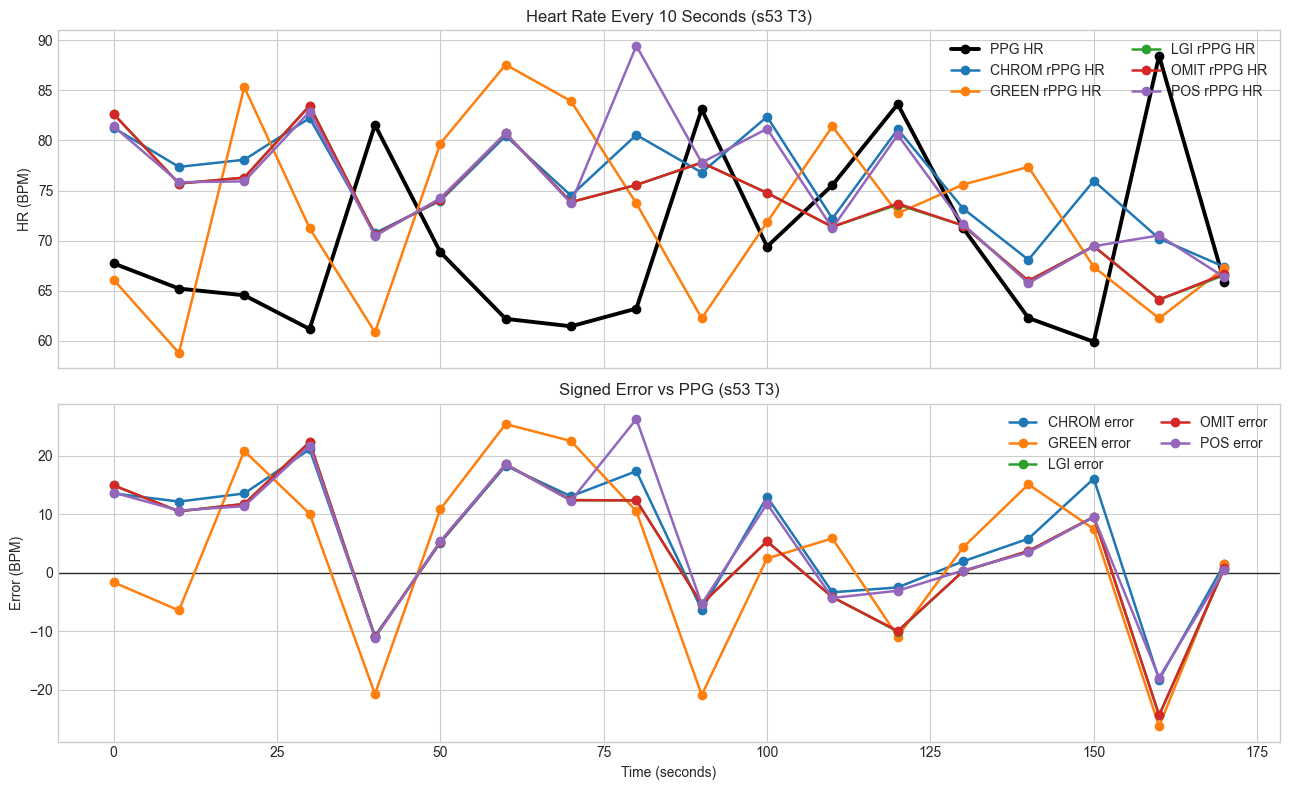

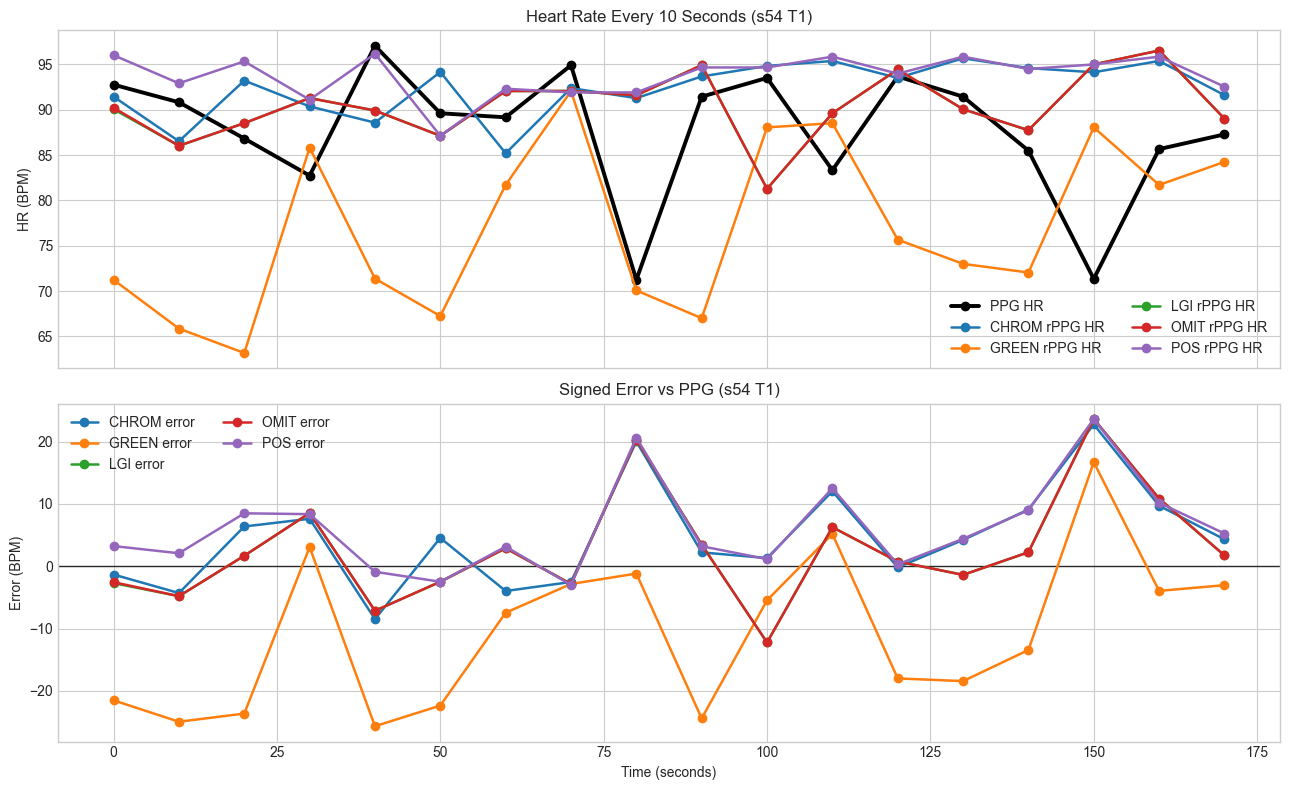

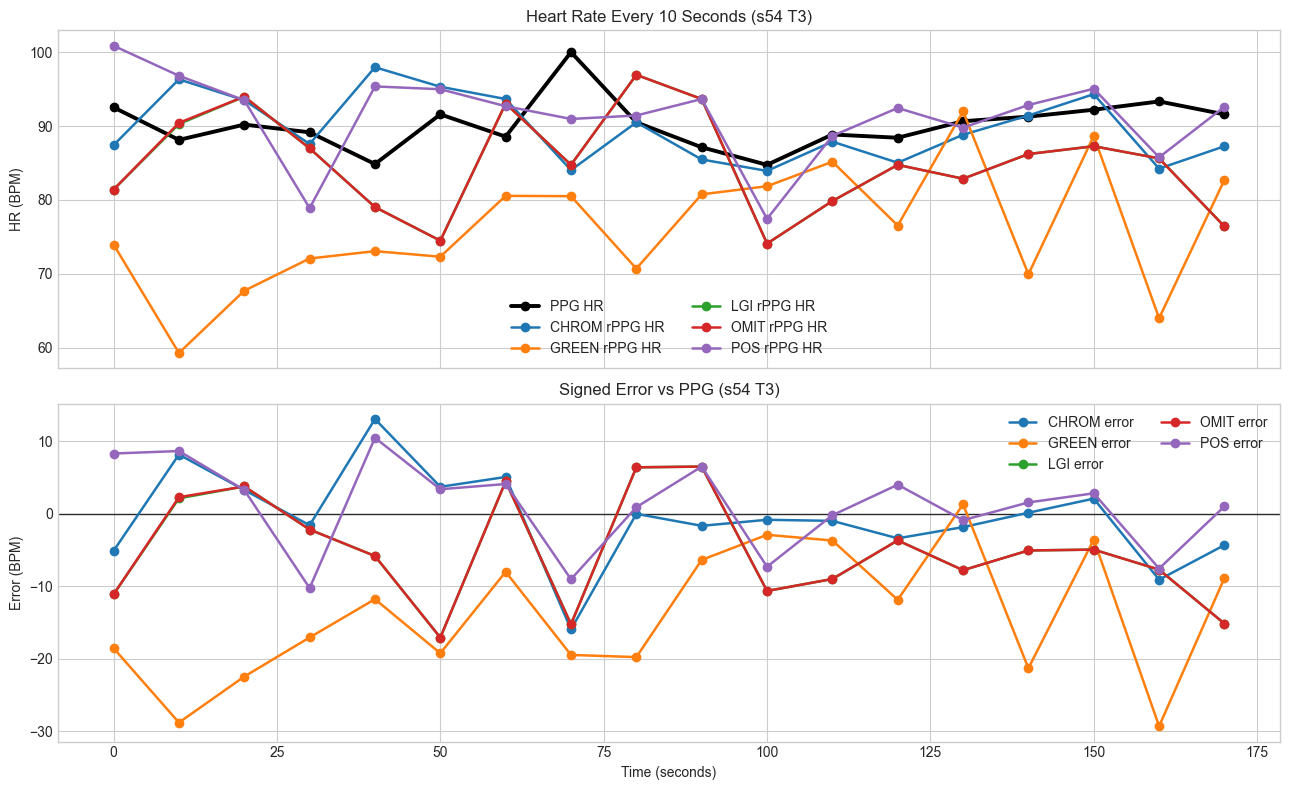

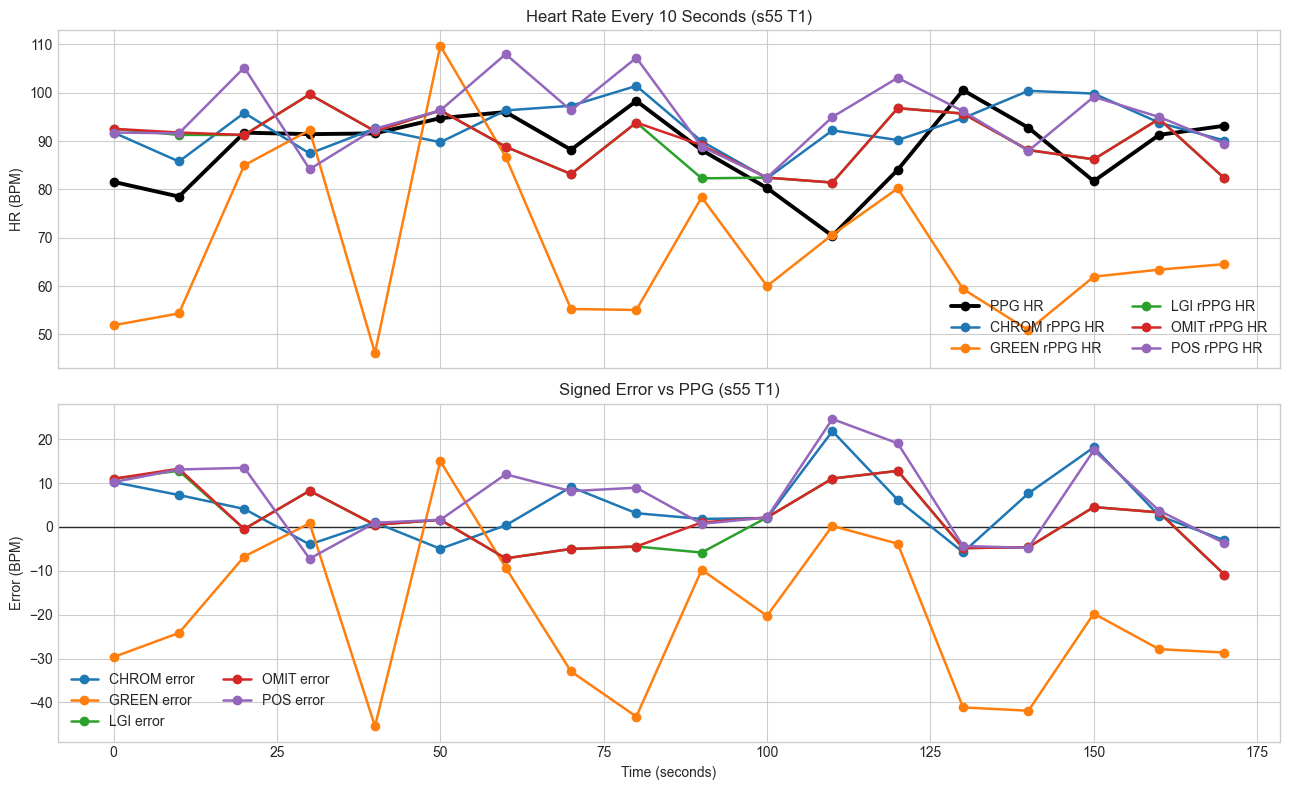

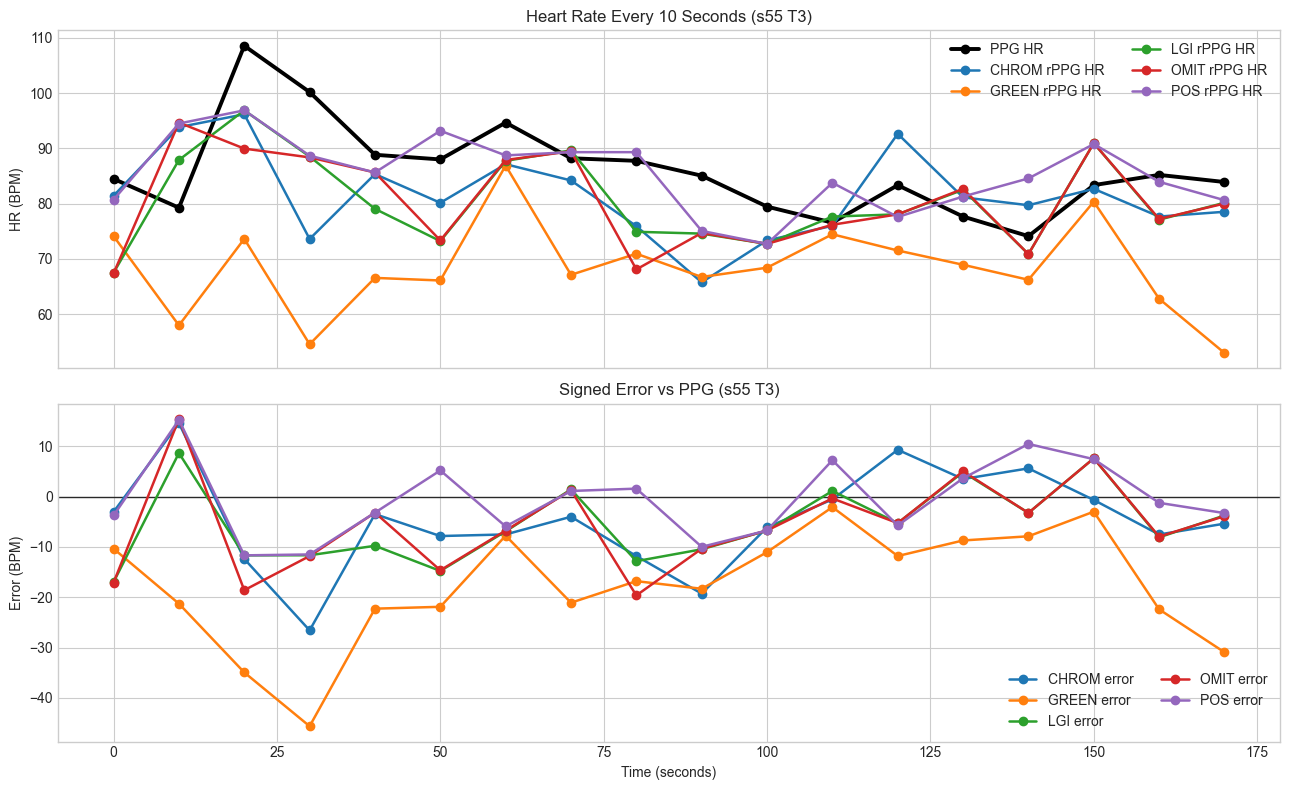

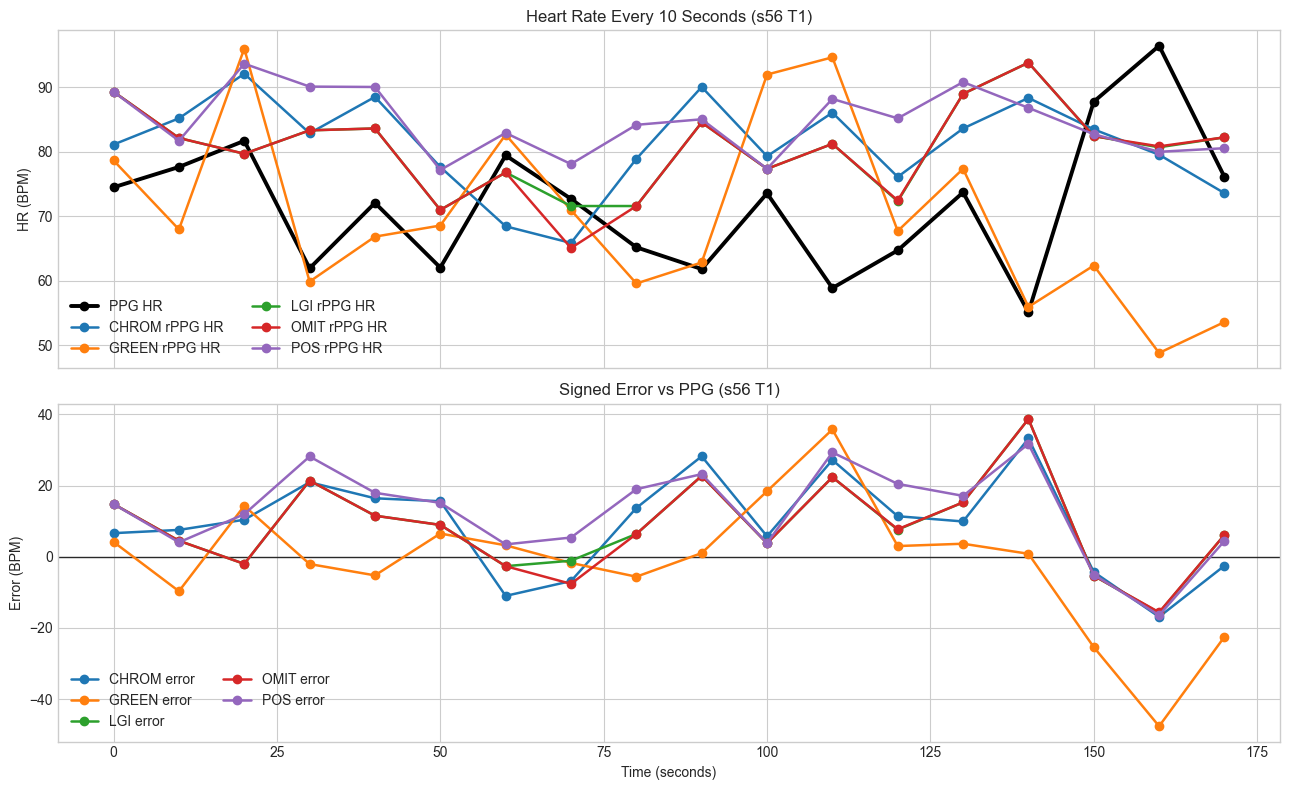

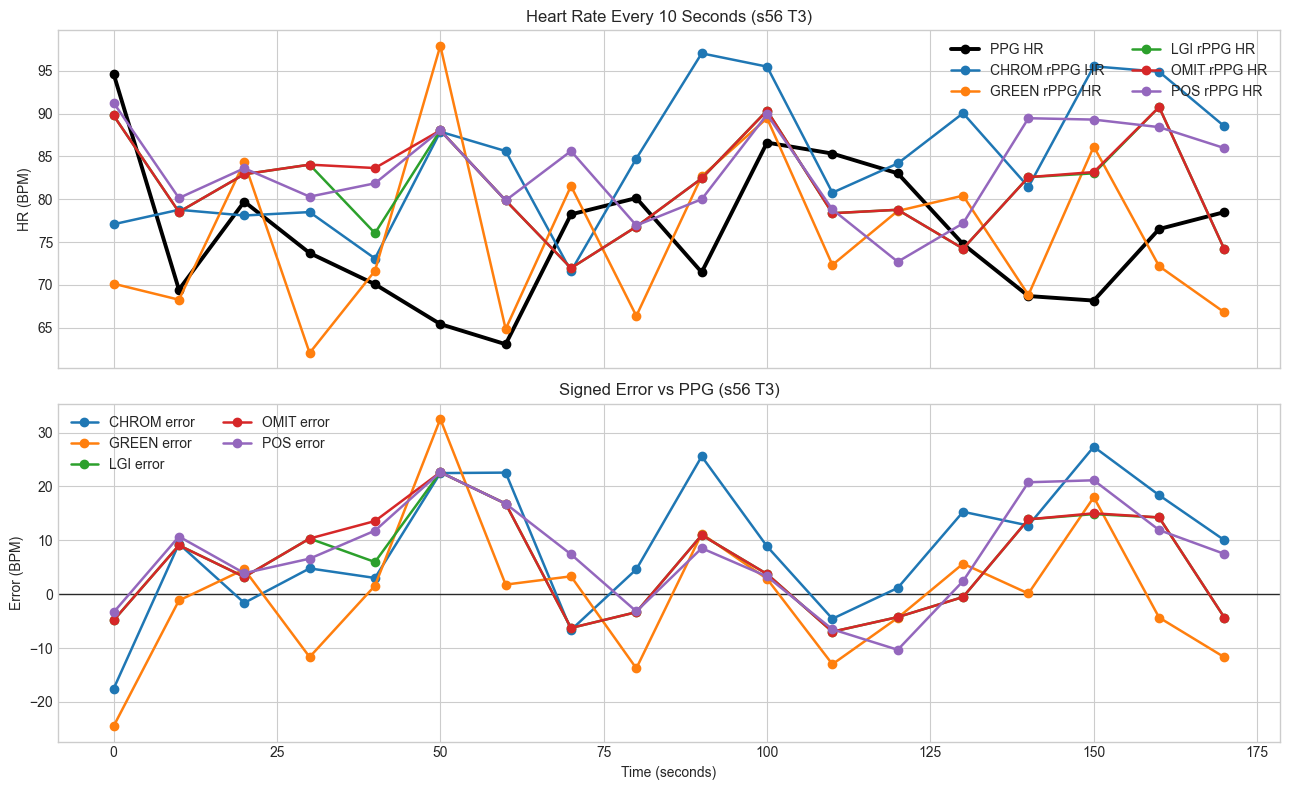

In [4]:
plt.style.use("seaborn-v0_8-whitegrid")

for subject in PLOT_SUBJECT:
    for trial in TRIALS:
        trial_df = comparison_df[(comparison_df["trial"] == trial) & (comparison_df["subject"] == subject)].copy()
        if trial_df.empty:
            continue

        ppg_line = trial_df.drop_duplicates(subset=["time_s"])[["time_s", "hr_ppg_bpm"]].sort_values("time_s")
        hr_pivot = trial_df.pivot(index="time_s", columns="method", values="hr_rppg_bpm").sort_index()
        err_pivot = trial_df.pivot(index="time_s", columns="method", values="signed_error_bpm").sort_index()

        fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

        axes[0].plot(
            ppg_line["time_s"],
            ppg_line["hr_ppg_bpm"],
            marker="o",
            linewidth=2.8,
            color="black",
            label="PPG HR",
        )

        for method in hr_pivot.columns:
            axes[0].plot(
                hr_pivot.index,
                hr_pivot[method],
                marker="o",
                linewidth=1.8,
                label=f"{method} rPPG HR",
            )

        axes[0].set_ylabel("HR (BPM)")
        axes[0].set_title(f"Heart Rate Every {WINDOW_SEC} Seconds ({subject} {trial})")
        axes[0].legend(loc="best", ncol=2)

        axes[1].axhline(0.0, color="black", linewidth=1, alpha=0.8)
        for method in err_pivot.columns:
            axes[1].plot(
                err_pivot.index,
                err_pivot[method],
                marker="o",
                linewidth=1.8,
                label=f"{method} error",
            )

        axes[1].set_xlabel("Time (seconds)")
        axes[1].set_ylabel("Error (BPM)")
        axes[1].set_title(f"Signed Error vs PPG ({subject} {trial})")
        axes[1].legend(loc="best", ncol=2)

        plt.tight_layout()
        plt.show()